<a href="https://colab.research.google.com/github/tejas448866/VoltRelay-Data-Analysis/blob/main/VoltRelay_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# VoltRelay Energy — Data Analytics

## Battery Swapping Network Analysis

**Objective:** Analyze network performance, service failures, station and battery performance, pricing, profitability, and rider retention to identify actionable business insights.

### Core Analysis Areas
1. Network Performance Over Time
2. Service Failures & Customer Experience
3. Station & Geographic Patterns
4. Battery & Equipment Performance
5. Pricing & Partner Economics
6. Rider Retention & Churn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
import os

files = os.listdir('/content')

print("Files available in Colab:")
for file in files:
    print(file)

Files available in Colab:
.config
fleet_partners.csv
support_tickets.csv
city_daily_context.csv
station_hourly_status.csv
stations.csv
batteries.csv
swap_events.csv
riders.csv
sample_data


In [ ]:
# Load all datasets

batteries = pd.read_csv('/content/batteries.csv')
city_context = pd.read_csv('/content/city_daily_context.csv')
fleet_partners = pd.read_csv('/content/fleet_partners.csv')
support_tickets = pd.read_csv('/content/support_tickets.csv')
station_status = pd.read_csv('/content/station_hourly_status.csv')
stations = pd.read_csv('/content/stations.csv')
riders = pd.read_csv('/content/riders.csv')
swap_events = pd.read_csv('/content/swap_events.csv')

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [ ]:
# Create a cleaned copy of swap events

swap_events_clean = swap_events.copy()

# Fix invalid kilometer values
swap_events_clean.loc[
    swap_events_clean['km_since_last_swap'] < 0,
    'km_since_last_swap'
] = np.nan

# Fix invalid SOC values
swap_events_clean.loc[
    swap_events_clean['soc_out_pct'] > 100,
    'soc_out_pct'
] = np.nan

# Fix invalid SOH values
swap_events_clean.loc[
    swap_events_clean['soh_in_pct'] > 100,
    'soh_in_pct'
] = np.nan

swap_events_clean.loc[
    swap_events_clean['soh_out_pct'] > 100,
    'soh_out_pct'
] = np.nan

# Create event categories
swap_events_clean['event_category'] = swap_events_clean['event_type'].map({
    'swap_completed': 'Completed',
    'failed_no_charged_battery': 'Failed',
    'failed_system_error': 'Failed',
    'abandoned_queue': 'Abandoned',
    'cancelled_by_rider': 'Cancelled'
})

print("swap_events_clean created successfully!")
print("Rows:", len(swap_events_clean))

swap_events_clean created successfully!
Rows: 2359242


In [ ]:
print("Cleaned dataset shape:", swap_events_clean.shape)

print("\nEvent categories:")
print(swap_events_clean['event_category'].value_counts())

print("\nMissing values after cleaning:")
print(
    swap_events_clean[
        ['km_since_last_swap', 'soc_out_pct', 'soh_in_pct', 'soh_out_pct']
    ].isna().sum()
)

Cleaned dataset shape: (2359242, 23)

Event categories:
event_category
Completed    2233208
Failed         78657
Abandoned      37298
Cancelled      10079
Name: count, dtype: int64

Missing values after cleaning:
km_since_last_swap     21920
soc_out_pct           128283
soh_in_pct             20514
soh_out_pct           128833
dtype: int64


In [ ]:
# Check dataset sizes

datasets = {
    "Swap Events": swap_events,
    "Station Status": station_status,
    "Riders": riders,
    "Batteries": batteries,
    "Support Tickets": support_tickets,
    "Stations": stations,
    "City Context": city_context,
    "Fleet Partners": fleet_partners
}

for name, df in datasets.items():
    print(f"{name}: {df.shape[0]:,} rows × {df.shape[1]} columns")

Swap Events: 2,359,242 rows × 22 columns
Station Status: 1,487,712 rows × 14 columns
Riders: 20,000 rows × 12 columns
Batteries: 6,500 rows × 13 columns
Support Tickets: 44,000 rows × 12 columns
Stations: 152 rows × 22 columns
City Context: 3,282 rows × 12 columns
Fleet Partners: 12 rows × 12 columns


In [ ]:
# Data Quality Check

for name, df in datasets.items():
    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print("Missing values:")
    print(df.isnull().sum()[df.isnull().sum() > 0])

    print("\nDuplicate rows:", df.duplicated().sum())


Swap Events
Missing values:
battery_in_id              17158
battery_out_id            126034
soc_in_pct                 17158
soh_in_pct                 17158
soc_out_pct               126034
soh_out_pct               126034
km_since_last_swap         17158
energy_to_recharge_kwh    126035
station_firmware               1
sync_mode                      1
dtype: int64

Duplicate rows: 0

Station Status
Missing values:
charged_2w_avg          9384
charged_2w_min          9384
charged_3w_min        821808
packs_charging          9384
packs_quarantined       9384
ambient_temp_c          9384
cabinet_temp_c          9384
avg_charge_minutes      9384
grid_kwh                9384
dtype: int64

Duplicate rows: 0

Riders
Missing values:
partner_id        7628
declared_shift    3662
age_band          1547
dtype: int64

Duplicate rows: 0

Batteries
Missing values:
retired_date         5062
retirement_reason    5062
dtype: int64

Duplicate rows: 0

Support Tickets
Missing values:
station_id     

In [ ]:
# Summary of missing values in all datasets

for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    if len(missing) == 0:
        print("No missing values")
    else:
        print(missing.sort_values(ascending=False))


Swap Events
energy_to_recharge_kwh    126035
battery_out_id            126034
soc_out_pct               126034
soh_out_pct               126034
battery_in_id              17158
soh_in_pct                 17158
soc_in_pct                 17158
km_since_last_swap         17158
station_firmware               1
sync_mode                      1
dtype: int64

Station Status
charged_3w_min        821808
charged_2w_avg          9384
charged_2w_min          9384
packs_charging          9384
packs_quarantined       9384
ambient_temp_c          9384
cabinet_temp_c          9384
avg_charge_minutes      9384
grid_kwh                9384
dtype: int64

Riders
partner_id        7628
declared_shift    3662
age_band          1547
dtype: int64

Batteries
retired_date         5062
retirement_reason    5062
dtype: int64

Support Tickets
csat_score          28871
battery_id          13235
resolution_hours     6112
station_id           2227
dtype: int64

Stations
decommissioned_date              151
competi

In [ ]:
# Check column names and data types

for name, df in datasets.items():
    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)
    print(df.dtypes)


Swap Events
event_id                   object
rider_id                   object
station_id                 object
event_ts                   object
event_type                 object
attempt_seq                 int64
queue_wait_sec              int64
battery_in_id              object
battery_out_id             object
soc_in_pct                float64
soh_in_pct                float64
soc_out_pct               float64
soh_out_pct               float64
km_since_last_swap        float64
tariff_code                object
list_price_inr            float64
discount_inr              float64
amount_charged_inr        float64
payment_mode               object
energy_to_recharge_kwh    float64
station_firmware           object
sync_mode                  object
dtype: object

Station Status
station_id             object
hour_start             object
charged_2w_avg        float64
charged_2w_min        float64
charged_3w_min        float64
packs_charging        float64
packs_quarantined     float64

In [ ]:
# View the first 5 rows of the main swap dataset

swap_events.head()

,event_id,rider_id,station_id,event_ts,event_type,attempt_seq,queue_wait_sec,battery_in_id,battery_out_id,soc_in_pct,soh_in_pct,soc_out_pct,soh_out_pct,km_since_last_swap,tariff_code,list_price_inr,discount_inr,amount_charged_inr,payment_mode,energy_to_recharge_kwh,station_firmware,sync_mode
0,SW-000000001,RD-1000003,STN-MUM-115,2024-01-01 11:10:56,swap_completed,1,88,BAT-2W-103542,BAT-2W-102547,15.0,100.6,98.7,98.9,80.4,PARTNER,60.0,6.0,54.0,partner_invoice,2.035,v3.2.1,realtime
1,SW-000000002,RD-1000004,STN-HYD-070,2024-01-01 17:13:06,swap_completed,1,148,BAT-2W-105296,BAT-2W-101923,8.3,98.3,97.3,98.2,66.1,PARTNER,60.0,9.0,51.0,partner_invoice,2.157,v3.2.0,realtime
2,SW-000000003,RD-1000005,STN-DEL-046,2024-01-01 20:15:14,swap_completed,1,307,BAT-2W-104732,BAT-2W-102492,11.5,99.1,99.8,99.1,66.6,STD,60.0,0.0,60.0,partner_invoice,2.039,v3.2.0,realtime
3,SW-000000004,RD-1000006,STN-JAI-135,2024-01-01 20:26:07,swap_completed,1,399,BAT-2W-103839,BAT-2W-103267,7.9,99.6,98.4,98.2,65.4,STD,60.0,0.0,60.0,partner_invoice,2.194,v3.2.0,realtime
4,SW-000000005,RD-1000012,STN-PUN-100,2024-01-01 21:13:07,swap_completed,1,201,BAT-2W-104056,BAT-2W-106218,10.5,99.2,95.6,99.9,73.8,STD,60.0,0.0,60.0,partner_invoice,1.971,v3.2.1,realtime


In [ ]:
# Convert date/time columns to proper datetime format

swap_events['event_ts'] = pd.to_datetime(swap_events['event_ts'], errors='coerce')

riders['signup_date'] = pd.to_datetime(riders['signup_date'], errors='coerce')

support_tickets['created_ts'] = pd.to_datetime(
    support_tickets['created_ts'], errors='coerce'
)

stations['commissioned_date'] = pd.to_datetime(
    stations['commissioned_date'], errors='coerce'
)

stations['decommissioned_date'] = pd.to_datetime(
    stations['decommissioned_date'], errors='coerce'
)

batteries['manufacture_date'] = pd.to_datetime(
    batteries['manufacture_date'], errors='coerce'
)

batteries['commission_date'] = pd.to_datetime(
    batteries['commission_date'], errors='coerce'
)

batteries['retired_date'] = pd.to_datetime(
    batteries['retired_date'], errors='coerce'
)

city_context['date'] = pd.to_datetime(
    city_context['date'], errors='coerce'
)

fleet_partners['contract_start_date'] = pd.to_datetime(
    fleet_partners['contract_start_date'], errors='coerce'
)

fleet_partners['amendment_date'] = pd.to_datetime(
    fleet_partners['amendment_date'], errors='coerce'
)

print("Date columns converted successfully!")

Date columns converted successfully!


In [ ]:
print("Rider home cities:")
print(sorted(riders['home_city'].dropna().unique()))

print("\nStation cities:")
print(sorted(stations['city'].dropna().unique()))

Rider home cities:
['BLR', 'Bangalore', 'Bengaluru', 'Bombay', 'Delhi', 'Delhi NCR', 'Gurgaon', 'HYD', 'Hyd', 'Hyderabad', 'JAI', 'Jaipur', 'MUM', 'Mumbai', 'New Delhi', 'PUN', 'Pune', 'bengaluru ', 'hyderabad', 'jaipur', 'pune']

Station cities:
['Bengaluru', 'Delhi NCR', 'Hyderabad', 'Jaipur', 'Mumbai', 'Pune']


In [ ]:
print("Unique rider cities:")
for city in sorted(riders['home_city'].dropna().unique()):
    print(repr(city))

Unique rider cities:
'BLR'
'Bangalore'
'Bengaluru'
'Bombay'
'Delhi'
'Delhi NCR'
'Gurgaon'
'HYD'
'Hyd'
'Hyderabad'
'JAI'
'Jaipur'
'MUM'
'Mumbai'
'New Delhi'
'PUN'
'Pune'
'bengaluru '
'hyderabad'
'jaipur'
'pune'


In [ ]:
city_mapping = {
    'BLR': 'Bengaluru',
    'Bangalore': 'Bengaluru',
    'Bengaluru': 'Bengaluru',
    'bengaluru ': 'Bengaluru',

    'Bombay': 'Mumbai',
    'MUM': 'Mumbai',
    'Mumbai': 'Mumbai',

    'Delhi': 'Delhi',
    'Delhi NCR': 'Delhi',
    'New Delhi': 'Delhi',

    'HYD': 'Hyderabad',
    'Hyd': 'Hyderabad',
    'Hyderabad': 'Hyderabad',
    'hyderabad': 'Hyderabad',

    'JAI': 'Jaipur',
    'Jaipur': 'Jaipur',
    'jaipur': 'Jaipur',

    'PUN': 'Pune',
    'Pune': 'Pune',
    'pune': 'Pune'
}

riders['home_city'] = riders['home_city'].replace(city_mapping)

print("City names standardized successfully!")

print("\nCleaned city names:")
print(sorted(riders['home_city'].dropna().unique()))

City names standardized successfully!

Cleaned city names:
['Bengaluru', 'Delhi', 'Gurgaon', 'Hyderabad', 'Jaipur', 'Mumbai', 'Pune']


In [ ]:
affected = swap_events[
    (swap_events['station_firmware'] == 'v3.2.0') &
    (swap_events['event_ts'] >= '2025-03-10') &
    (swap_events['event_ts'] < '2025-04-15')
]

print("Potentially affected records:", len(affected))

Potentially affected records: 0


In [ ]:
v32 = swap_events[
    swap_events['station_firmware'] == 'v3.2.0'
]

print("Total v3.2.0 records:", len(v32))

if len(v32) > 0:
    print("Earliest v3.2.0 timestamp:", v32['event_ts'].min())
    print("Latest v3.2.0 timestamp:", v32['event_ts'].max())
else:
    print("No v3.2.0 records found.")

Total v3.2.0 records: 958503
Earliest v3.2.0 timestamp: 2024-01-01 00:09:00
Latest v3.2.0 timestamp: 2025-02-05 23:59:30


In [ ]:
affected = swap_events[
    (swap_events['station_firmware'] == 'v3.2.0') &
    (swap_events['event_ts'] >= '2025-03-09 18:30:00') &
    (swap_events['event_ts'] < '2025-04-14 18:30:00')
]

print("Potentially affected records:", len(affected))

if len(affected) > 0:
    print("First affected timestamp:", affected['event_ts'].min())
    print("Last affected timestamp:", affected['event_ts'].max())

Potentially affected records: 0


In [ ]:
print("Swap event date range:")
print("Earliest:", swap_events['event_ts'].min())
print("Latest  :", swap_events['event_ts'].max())

print("\nFirmware versions:")
print(swap_events['station_firmware'].value_counts())

Swap event date range:
Earliest: 2024-01-01 00:00:33
Latest  : 2025-02-05 23:59:30

Firmware versions:
station_firmware
v3.2.1    1400738
v3.2.0     958503
Name: count, dtype: int64


### Timestamp Validation

The dataset contains swap events from January 1, 2024 to May 26, 2024.
The documented firmware v3.2.0 timestamp issue applies to March 10–April 14, 2025.
Since this dataset does not contain records from that period, no timestamp correction was applied.

In [ ]:
print(swap_events['sync_mode'].value_counts())

sync_mode
realtime         1993933
offline_batch     365308
Name: count, dtype: int64


In [ ]:
offline_events = swap_events[
    swap_events['sync_mode'] == 'offline_batch'
]

print("Offline batch records:", len(offline_events))
print("Exact duplicate rows:", offline_events.duplicated().sum())

Offline batch records: 365308
Exact duplicate rows: 0


In [ ]:
near_dup_check = swap_events[
    swap_events['sync_mode'] == 'offline_batch'
].copy()

duplicate_columns = [
    'rider_id',
    'station_id',
    'event_ts',
    'event_type',
    'battery_in_id',
    'battery_out_id'
]

near_duplicates = near_dup_check[
    near_dup_check.duplicated(
        subset=duplicate_columns,
        keep=False
    )
]

print("Potential near-duplicate records:", len(near_duplicates))

if len(near_duplicates) > 0:
    print("\nSample potential near-duplicates:")
    display(
        near_duplicates[
            duplicate_columns
        ].sort_values(duplicate_columns).head(20)
    )

Potential near-duplicate records: 0


In [ ]:
near_dup_check = swap_events[
    swap_events['sync_mode'] == 'offline_batch'
].copy()

duplicate_columns = [
    'rider_id',
    'station_id',
    'event_ts',
    'event_type',
    'battery_in_id',
    'battery_out_id'
]

near_duplicates = near_dup_check[
    near_dup_check.duplicated(
        subset=duplicate_columns,
        keep=False
    )
]

print("Potential near-duplicate records:", len(near_duplicates))

if len(near_duplicates) > 0:
    print("\nSample potential near-duplicates:")
    display(
        near_duplicates[
            duplicate_columns
        ].sort_values(duplicate_columns).head(20)
    )

Potential near-duplicate records: 0


In [ ]:
print("KM since last swap")
print("Minimum:", swap_events['km_since_last_swap'].min())
print("Maximum:", swap_events['km_since_last_swap'].max())

print("\nSOC values")
print("Minimum:", swap_events['soc_in_pct'].min())
print("Maximum:", swap_events['soc_in_pct'].max())

print("\nSOH values")
print("Minimum:", swap_events['soh_in_pct'].min())
print("Maximum:", swap_events['soh_in_pct'].max())

print("\nSOC OUT values")
print("Minimum:", swap_events['soc_out_pct'].min())
print("Maximum:", swap_events['soc_out_pct'].max())

print("\nSOH OUT values")
print("Minimum:", swap_events['soh_out_pct'].min())
print("Maximum:", swap_events['soh_out_pct'].max())

KM since last swap
Minimum: -20.0
Maximum: 420.0

SOC values
Minimum: 1.0
Maximum: 28.4

SOH values
Minimum: 78.0
Maximum: 101.4

SOC OUT values
Minimum: 80.0
Maximum: 103.0

SOH OUT values
Minimum: 77.8
Maximum: 101.3


In [ ]:
print("Invalid km_since_last_swap:",
      (swap_events['km_since_last_swap'] < 0).sum())

print("Invalid soc_out_pct:",
      (swap_events['soc_out_pct'] > 100).sum())

print("Invalid soh_in_pct:",
      (swap_events['soh_in_pct'] > 100).sum())

print("Invalid soh_out_pct:",
      (swap_events['soh_out_pct'] > 100).sum())

Invalid km_since_last_swap: 4762
Invalid soc_out_pct: 2249
Invalid soh_in_pct: 3356
Invalid soh_out_pct: 2799


In [ ]:
swap_events_clean = swap_events.copy()

# Invalid distance values
swap_events_clean.loc[
    swap_events_clean['km_since_last_swap'] < 0,
    'km_since_last_swap'
] = np.nan

# Invalid percentage values above 100%
swap_events_clean.loc[
    swap_events_clean['soc_out_pct'] > 100,
    'soc_out_pct'
] = np.nan

swap_events_clean.loc[
    swap_events_clean['soh_in_pct'] > 100,
    'soh_in_pct'
] = np.nan

swap_events_clean.loc[
    swap_events_clean['soh_out_pct'] > 100,
    'soh_out_pct'
] = np.nan

print("Invalid numerical values handled successfully.")

print("\nRemaining invalid values:")
print(
    "Negative km:",
    (swap_events_clean['km_since_last_swap'] < 0).sum()
)
print(
    "SOC out > 100:",
    (swap_events_clean['soc_out_pct'] > 100).sum()
)
print(
    "SOH in > 100:",
    (swap_events_clean['soh_in_pct'] > 100).sum()
)
print(
    "SOH out > 100:",
    (swap_events_clean['soh_out_pct'] > 100).sum()
)

Invalid numerical values handled successfully.

Remaining invalid values:
Negative km: 0
SOC out > 100: 0
SOH in > 100: 0
SOH out > 100: 0


In [ ]:
print("Event types:")
print(
    swap_events_clean['event_type']
    .value_counts()
)

Event types:
event_type
swap_completed               2233208
failed_no_charged_battery      71578
abandoned_queue                37298
cancelled_by_rider             10079
failed_system_error             7079
Name: count, dtype: int64


In [ ]:
swap_events_clean['event_category'] = swap_events_clean['event_type'].map({
    'swap_completed': 'Completed',
    'failed_no_charged_battery': 'Failed',
    'failed_system_error': 'Failed',
    'abandoned_queue': 'Abandoned',
    'cancelled_by_rider': 'Cancelled'
})

print("Event category created successfully!")

print(
    swap_events_clean['event_category'].value_counts()
)

Event category created successfully!
event_category
Completed    2233208
Failed         78657
Abandoned      37298
Cancelled      10079
Name: count, dtype: int64


In [ ]:
swap_events_clean['month'] = swap_events_clean['event_ts'].dt.to_period('M').astype(str)

monthly_swaps = (
    swap_events_clean[
        swap_events_clean['event_category'] == 'Completed'
    ]
    .groupby('month')
    .size()
    .reset_index(name='completed_swaps')
)

print(monthly_swaps)

      month  completed_swaps
0   2024-01           105490
1   2024-02           106582
2   2024-03           118444
3   2024-04           122836
4   2024-05           128328
5   2024-06           133743
6   2024-07           151824
7   2024-08           164931
8   2024-09           187302
9   2024-10           219838
10  2024-11           228253
11  2024-12           252621
12  2025-01           269843
13  2025-02            43173


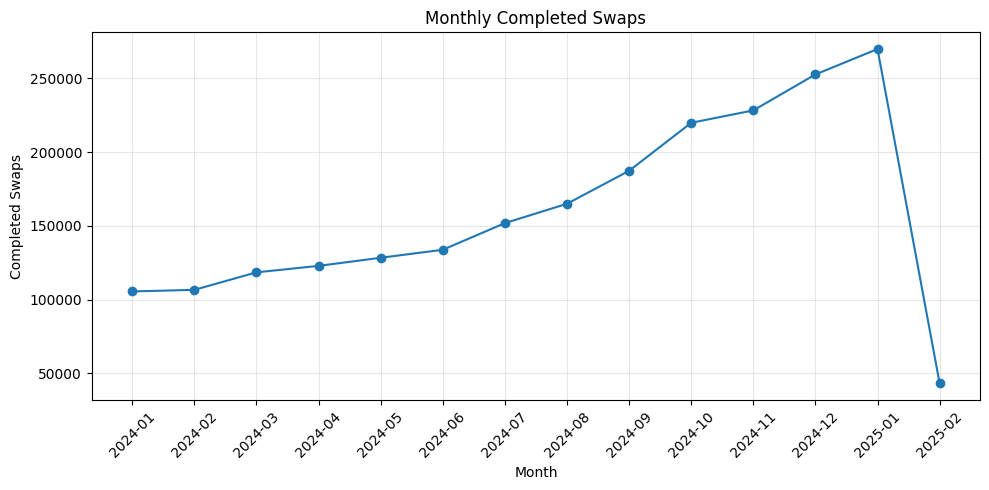

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_swaps['month'],
    monthly_swaps['completed_swaps'],
    marker='o'
)

plt.title('Monthly Completed Swaps')
plt.xlabel('Month')
plt.ylabel('Completed Swaps')

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [ ]:
# Convert event timestamp back to datetime

swap_events_clean['event_ts'] = pd.to_datetime(
    swap_events_clean['event_ts'],
    errors='coerce'
)

print("event_ts converted to datetime!")
print(swap_events_clean['event_ts'].dtype)

event_ts converted to datetime!
datetime64[ns]


In [ ]:
# Create month column for monthly analysis

swap_events_clean['month'] = (
    swap_events_clean['event_ts']
    .dt.to_period('M')
    .astype(str)
)

print("Month column created successfully!")
print(swap_events_clean['month'].head())

Month column created successfully!
0    2024-01
1    2024-01
2    2024-01
3    2024-01
4    2024-01
Name: month, dtype: object


In [ ]:
monthly_performance = (
    swap_events_clean
    .groupby('month')
    .agg(
        total_attempts=('event_id', 'count'),
        completed_swaps=('event_category', lambda x: (x == 'Completed').sum()),
        failed_attempts=('event_category', lambda x: (x == 'Failed').sum()),
        abandoned_attempts=('event_category', lambda x: (x == 'Abandoned').sum()),
        cancelled_attempts=('event_category', lambda x: (x == 'Cancelled').sum()),
        revenue_inr=('amount_charged_inr', 'sum')
    )
    .reset_index()
)

monthly_performance['failure_rate_pct'] = (
    monthly_performance['failed_attempts']
    / monthly_performance['total_attempts']
    * 100
)

print(monthly_performance.round(2))

      month  total_attempts  completed_swaps  failed_attempts  \
0   2024-01          110348           105490             3008   
1   2024-02          111531           106582             3027   
2   2024-03          123900           118444             3332   
3   2024-04          131818           122836             5775   
4   2024-05          146278           128328            11760   
5   2024-06          148888           133743             9911   
6   2024-07          158688           151824             4186   
7   2024-08          172295           164931             4424   
8   2024-09          195885           187302             5311   
9   2024-10          229901           219838             6148   
10  2024-11          238352           228253             6131   
11  2024-12          264265           252621             7091   
12  2025-01          281957           269843             7376   
13  2025-02           45136            43173             1177   

    abandoned_attempts  

In [ ]:
print('month' in swap_events_clean.columns)

True


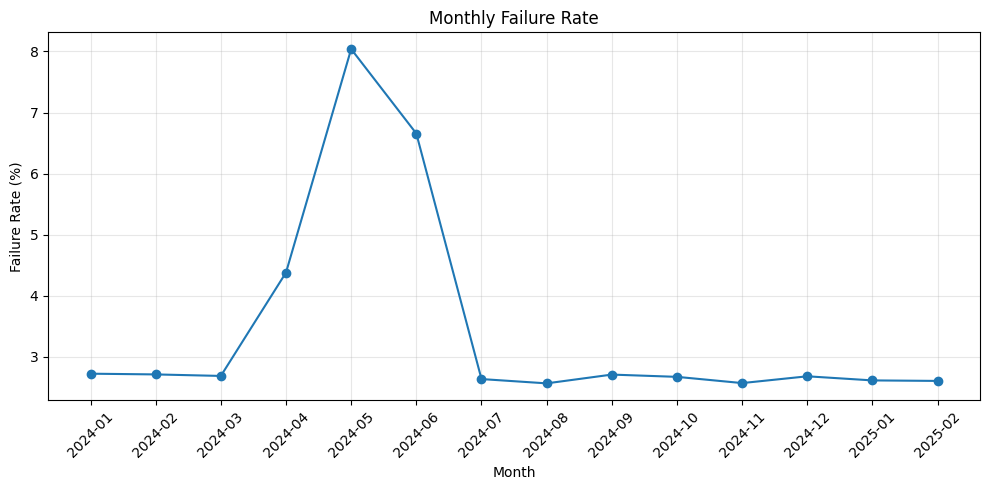

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_performance['month'],
    monthly_performance['failure_rate_pct'],
    marker='o'
)

plt.title('Monthly Failure Rate')
plt.xlabel('Month')
plt.ylabel('Failure Rate (%)')

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [ ]:
failure_events = swap_events_clean[
    swap_events_clean['event_category'] == 'Failed'
]

failure_reasons = (
    failure_events['event_type']
    .value_counts()
    .reset_index()
)

failure_reasons.columns = ['failure_reason', 'count']

failure_reasons['percentage'] = (
    failure_reasons['count']
    / failure_reasons['count'].sum()
    * 100
)

print(failure_reasons.round(2))

              failure_reason  count  percentage
0  failed_no_charged_battery  71578        91.0
1        failed_system_error   7079         9.0


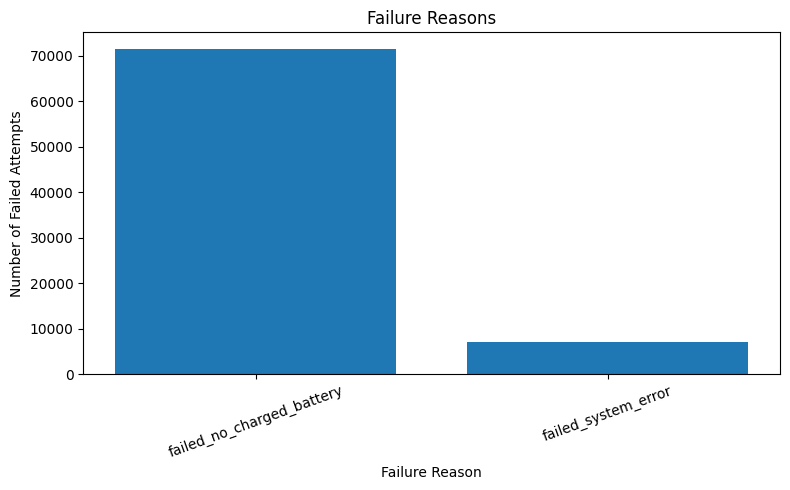

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    failure_reasons['failure_reason'],
    failure_reasons['count']
)

plt.title('Failure Reasons')
plt.xlabel('Failure Reason')
plt.ylabel('Number of Failed Attempts')

plt.xticks(rotation=20)
plt.tight_layout()

plt.show()

In [ ]:
station_failures = (
    failure_events
    .groupby('station_id')
    .size()
    .reset_index(name='failed_attempts')
    .sort_values('failed_attempts', ascending=False)
)

print("Top 10 stations by failed attempts:")
display(station_failures.head(10))

Top 10 stations by failed attempts:


,station_id,failed_attempts
77,STN-JAI-138,1540
79,STN-JAI-140,1339
76,STN-JAI-137,1305
36,STN-DEL-043,1298
57,STN-HYD-070,1295
80,STN-JAI-141,1293
43,STN-DEL-050,1254
59,STN-HYD-072,1251
73,STN-JAI-134,1247
40,STN-DEL-047,1226


In [ ]:
station_performance = (
    swap_events_clean
    .groupby('station_id')
    .agg(
        total_attempts=('event_id', 'count'),
        failed_attempts=('event_category', lambda x: (x == 'Failed').sum()),
        completed_swaps=('event_category', lambda x: (x == 'Completed').sum())
    )
    .reset_index()
)

station_performance['failure_rate_pct'] = (
    station_performance['failed_attempts']
    / station_performance['total_attempts']
    * 100
)

station_performance = station_performance.sort_values(
    'failure_rate_pct',
    ascending=False
)

print("Top 10 stations by failure rate:")
display(
    station_performance.head(10).round(2)
)

Top 10 stations by failure rate:


,station_id,total_attempts,failed_attempts,completed_swaps,failure_rate_pct
30,STN-DEL-037,19641,936,18205,4.77
72,STN-JAI-133,19586,931,18141,4.75
81,STN-JAI-142,23676,1080,21958,4.56
77,STN-JAI-138,33865,1540,31463,4.55
78,STN-JAI-139,23110,1048,21468,4.53
75,STN-JAI-136,21132,954,19639,4.51
32,STN-DEL-039,21798,971,20273,4.45
76,STN-JAI-137,29569,1305,27505,4.41
79,STN-JAI-140,30495,1339,28430,4.39
42,STN-DEL-049,15838,692,14771,4.37


In [ ]:
city_data = stations[['station_id', 'city']].copy()

city_performance = swap_events_clean.merge(
    city_data,
    on='station_id',
    how='left'
)

city_performance = (
    city_performance
    .groupby('city')
    .agg(
        total_attempts=('event_id', 'count'),
        completed_swaps=('event_category', lambda x: (x == 'Completed').sum()),
        failed_attempts=('event_category', lambda x: (x == 'Failed').sum()),
        abandoned_attempts=('event_category', lambda x: (x == 'Abandoned').sum())
    )
    .reset_index()
)

city_performance['failure_rate_pct'] = (
    city_performance['failed_attempts']
    / city_performance['total_attempts']
    * 100
)

city_performance['abandonment_rate_pct'] = (
    city_performance['abandoned_attempts']
    / city_performance['total_attempts']
    * 100
)

city_performance = city_performance.sort_values(
    'failure_rate_pct',
    ascending=False
)

display(city_performance.round(2))

,city,total_attempts,completed_swaps,failed_attempts,abandoned_attempts,failure_rate_pct,abandonment_rate_pct
3,Jaipur,295818,276079,12555,5943,4.24,2.01
1,Delhi NCR,458237,430365,17509,8372,3.82,1.83
2,Hyderabad,427576,402912,15549,7334,3.64,1.72
5,Pune,343697,327290,10095,4873,2.94,1.42
0,Bengaluru,510194,487268,14095,6651,2.76,1.30
4,Mumbai,323720,309294,8854,4125,2.74,1.27


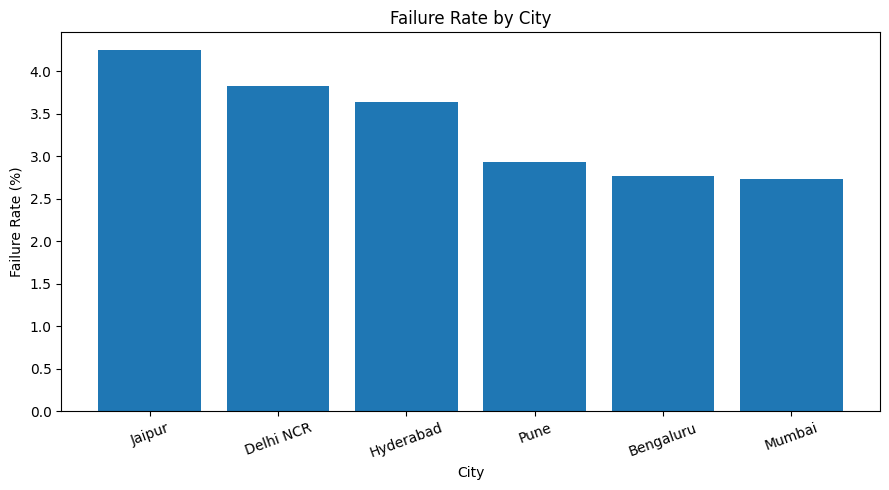

In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(
    city_performance['city'],
    city_performance['failure_rate_pct']
)

plt.title('Failure Rate by City')
plt.xlabel('City')
plt.ylabel('Failure Rate (%)')

plt.xticks(rotation=20)
plt.tight_layout()

plt.show()

In [ ]:
print("Station Status columns:")

for i, column in enumerate(station_status.columns):
    print(i, ":", column)

Station Status columns:
0 : station_id
1 : hour_start
2 : charged_2w_avg
3 : charged_2w_min
4 : charged_3w_min
5 : packs_charging
6 : packs_quarantined
7 : chargers_online
8 : ambient_temp_c
9 : cabinet_temp_c
10 : avg_charge_minutes
11 : outage_minutes
12 : grid_kwh
13 : telemetry_status


In [ ]:
station_city = stations[['station_id', 'city']].copy()

status_city = station_status.merge(
    station_city,
    on='station_id',
    how='left'
)

city_battery = (
    status_city
    .groupby('city')
    .agg(
        avg_charged_2w=('charged_2w_avg', 'mean'),
        avg_min_charged_2w=('charged_2w_min', 'mean'),
        avg_packs_charging=('packs_charging', 'mean'),
        avg_packs_quarantined=('packs_quarantined', 'mean'),
        avg_chargers_online=('chargers_online', 'mean'),
        avg_outage_minutes=('outage_minutes', 'mean')
    )
    .reset_index()
)

city_battery = city_battery.sort_values(
    'avg_charged_2w',
    ascending=True
)

display(city_battery.round(2))

,city,avg_charged_2w,avg_min_charged_2w,avg_packs_charging,avg_packs_quarantined,avg_chargers_online,avg_outage_minutes
0,Bengaluru,8.08,6.57,3.96,0.0,13.32,0.01
1,Delhi NCR,8.15,6.66,4.19,0.0,14.04,0.01
3,Jaipur,8.32,6.84,4.37,0.0,14.71,0.01
2,Hyderabad,8.47,6.97,4.68,0.0,15.73,0.00
4,Mumbai,9.56,8.06,4.53,0.0,15.21,0.03
5,Pune,10.27,8.77,4.88,0.0,16.44,0.01


In [ ]:
swap_events_clean['hour'] = swap_events_clean['event_ts'].dt.hour

hourly_performance = (
    swap_events_clean
    .groupby('hour')
    .agg(
        total_attempts=('event_id', 'count'),
        failed_attempts=('event_category', lambda x: (x == 'Failed').sum()),
        completed_swaps=('event_category', lambda x: (x == 'Completed').sum()),
        abandoned_attempts=('event_category', lambda x: (x == 'Abandoned').sum())
    )
    .reset_index()
)

hourly_performance['failure_rate_pct'] = (
    hourly_performance['failed_attempts']
    / hourly_performance['total_attempts']
    * 100
)

hourly_performance['abandonment_rate_pct'] = (
    hourly_performance['abandoned_attempts']
    / hourly_performance['total_attempts']
    * 100
)

display(hourly_performance.round(2))

,hour,total_attempts,failed_attempts,completed_swaps,abandoned_attempts,failure_rate_pct,abandonment_rate_pct
0,0,13636,447,12931,206,3.28,1.51
1,1,13376,414,12693,210,3.10,1.57
2,2,13453,432,12774,186,3.21,1.38
3,3,13556,408,12864,216,3.01,1.59
4,4,14877,466,14146,209,3.13,1.40
5,5,14661,431,13940,232,2.94,1.58
6,6,33754,1062,32037,509,3.15,1.51
7,7,33920,1061,32173,519,3.13,1.53
8,8,102129,3332,96766,1615,3.26,1.58
9,9,144124,4566,136749,2157,3.17,1.50


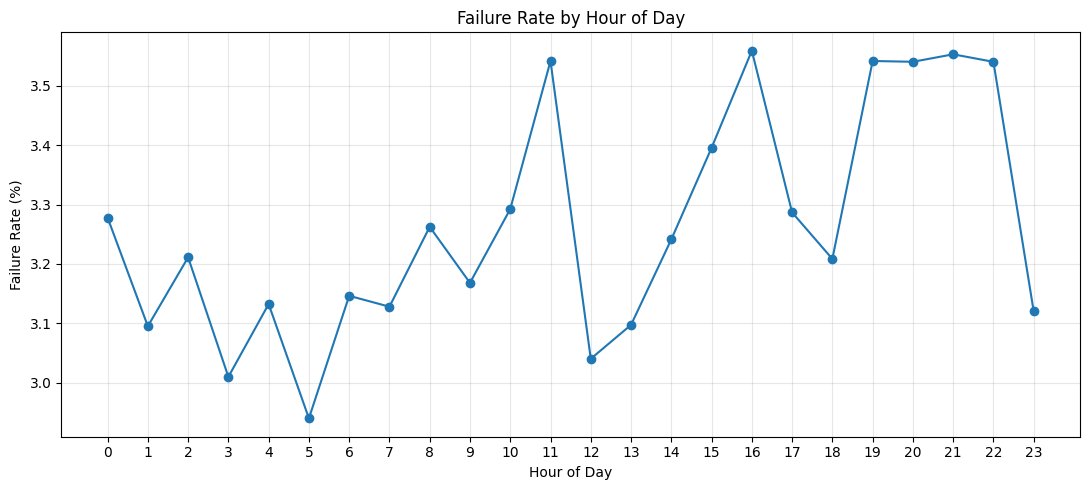

In [ ]:
plt.figure(figsize=(11, 5))

plt.plot(
    hourly_performance['hour'],
    hourly_performance['failure_rate_pct'],
    marker='o'
)

plt.title('Failure Rate by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Failure Rate (%)')

plt.xticks(range(24))
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [ ]:
station_status['hour'] = pd.to_datetime(
    station_status['hour_start'],
    errors='coerce'
).dt.hour

hourly_battery = (
    station_status
    .groupby('hour')
    .agg(
        avg_charged_2w=('charged_2w_avg', 'mean'),
        avg_min_charged_2w=('charged_2w_min', 'mean'),
        avg_packs_charging=('packs_charging', 'mean'),
        avg_outage_minutes=('outage_minutes', 'mean')
    )
    .reset_index()
)

display(hourly_battery.round(2))

,hour,avg_charged_2w,avg_min_charged_2w,avg_packs_charging,avg_outage_minutes
0,0,9.72,8.22,3.31,0.02
1,1,9.73,8.22,3.32,0.01
2,2,9.73,8.23,3.32,0.01
3,3,9.73,8.23,3.32,0.01
4,4,9.71,8.21,3.32,0.01
5,5,9.72,8.22,3.32,0.01
6,6,9.66,8.16,3.39,0.01
7,7,9.51,8.01,3.56,0.02
8,8,9.27,7.76,3.85,0.01
9,9,8.99,7.49,4.21,0.01


In [ ]:
battery_failure_hourly = (
    swap_events_clean[
        swap_events_clean['event_type'] == 'failed_no_charged_battery'
    ]
    .groupby('hour')
    .size()
    .reset_index(name='battery_failure_count')
)

hourly_attempts = (
    swap_events_clean
    .groupby('hour')
    .size()
    .reset_index(name='total_attempts')
)

battery_failure_hourly = battery_failure_hourly.merge(
    hourly_attempts,
    on='hour',
    how='right'
)

battery_failure_hourly['battery_failure_rate_pct'] = (
    battery_failure_hourly['battery_failure_count'].fillna(0)
    / battery_failure_hourly['total_attempts']
    * 100
)

battery_failure_hourly = battery_failure_hourly.sort_values('hour')

display(battery_failure_hourly.round(2))

,hour,battery_failure_count,total_attempts,battery_failure_rate_pct
0,0,400,13636,2.93
1,1,382,13376,2.86
2,2,395,13453,2.94
3,3,362,13556,2.67
4,4,424,14877,2.85
5,5,388,14661,2.65
6,6,952,33754,2.82
7,7,949,33920,2.80
8,8,3046,102129,2.98
9,9,4136,144124,2.87


In [ ]:
battery_failure_hourly = (
    swap_events_clean[
        swap_events_clean['event_type'] == 'failed_no_charged_battery'
    ]
    .groupby('hour')
    .size()
    .reset_index(name='battery_failure_count')
)

hourly_attempts = (
    swap_events_clean
    .groupby('hour')
    .size()
    .reset_index(name='total_attempts')
)

battery_failure_hourly = battery_failure_hourly.merge(
    hourly_attempts,
    on='hour',
    how='right'
)

battery_failure_hourly['battery_failure_rate_pct'] = (
    battery_failure_hourly['battery_failure_count'].fillna(0)
    / battery_failure_hourly['total_attempts']
    * 100
)

battery_failure_hourly = battery_failure_hourly.sort_values('hour')

display(battery_failure_hourly.round(2))

,hour,battery_failure_count,total_attempts,battery_failure_rate_pct
0,0,400,13636,2.93
1,1,382,13376,2.86
2,2,395,13453,2.94
3,3,362,13556,2.67
4,4,424,14877,2.85
5,5,388,14661,2.65
6,6,952,33754,2.82
7,7,949,33920,2.80
8,8,3046,102129,2.98
9,9,4136,144124,2.87


In [ ]:
print("Battery columns:")

for i, column in enumerate(batteries.columns):
    print(i, ":", column)

Battery columns:
0 : battery_id
1 : pack_type
2 : supplier
3 : manufacturing_lot
4 : manufacture_date
5 : commission_date
6 : rated_capacity_kwh
7 : purchase_cost_inr
8 : initial_soh_pct
9 : bms_firmware
10 : retired_date
11 : retirement_reason
12 : current_soh_pct


In [ ]:
print("Battery pack types:")
print(batteries['pack_type'].value_counts())

Battery pack types:
pack_type
2W_2.1kWh    5518
3W_4.8kWh     982
Name: count, dtype: int64


In [ ]:
battery_type_data = batteries[['battery_id', 'pack_type']].copy()

vehicle_analysis = swap_events_clean.merge(
    battery_type_data,
    left_on='battery_in_id',
    right_on='battery_id',
    how='left'
)

vehicle_performance = (
    vehicle_analysis
    .groupby('pack_type')
    .agg(
        total_attempts=('event_id', 'count'),
        completed_swaps=('event_category', lambda x: (x == 'Completed').sum()),
        failed_attempts=('event_category', lambda x: (x == 'Failed').sum()),
        no_charged_battery_failures=(
            'event_type',
            lambda x: (x == 'failed_no_charged_battery').sum()
        ),
        abandoned_attempts=('event_category', lambda x: (x == 'Abandoned').sum())
    )
    .reset_index()
)

vehicle_performance['failure_rate_pct'] = (
    vehicle_performance['failed_attempts']
    / vehicle_performance['total_attempts']
    * 100
)

vehicle_performance['no_battery_failure_rate_pct'] = (
    vehicle_performance['no_charged_battery_failures']
    / vehicle_performance['total_attempts']
    * 100
)

vehicle_performance['abandonment_rate_pct'] = (
    vehicle_performance['abandoned_attempts']
    / vehicle_performance['total_attempts']
    * 100
)

display(vehicle_performance.round(2))

,pack_type,total_attempts,completed_swaps,failed_attempts,no_charged_battery_failures,abandoned_attempts,failure_rate_pct,no_battery_failure_rate_pct,abandonment_rate_pct
0,2W_2.1kWh,2083179,1998171,55745,55745,29263,2.68,2.68,1.4
1,3W_4.8kWh,258905,235037,15833,15833,8035,6.12,6.12,3.1


In [ ]:
print("Battery SOH summary:")

print(
    batteries['current_soh_pct']
    .describe()
    .round(2)
)

Battery SOH summary:
count    6500.00
mean       76.61
std         8.82
min        55.40
25%        78.40
50%        79.80
75%        80.80
max        88.60
Name: current_soh_pct, dtype: float64


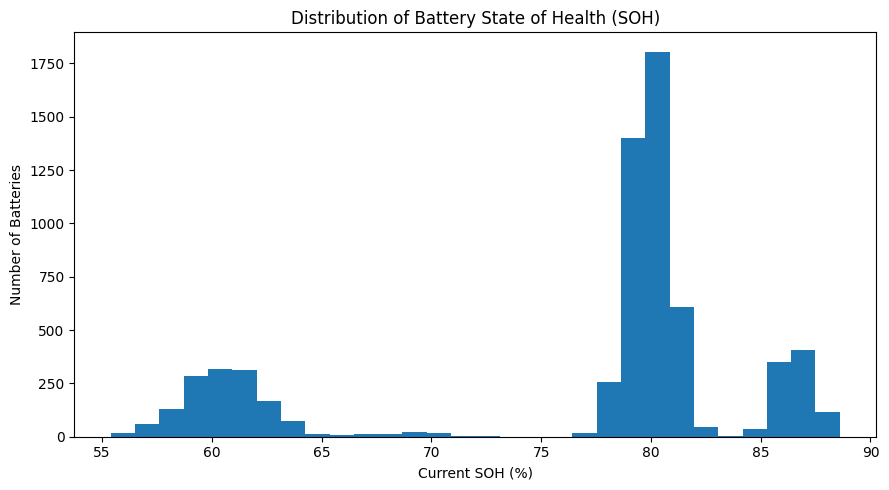

In [ ]:
plt.figure(figsize=(9, 5))

plt.hist(
    batteries['current_soh_pct'].dropna(),
    bins=30
)

plt.title('Distribution of Battery State of Health (SOH)')
plt.xlabel('Current SOH (%)')
plt.ylabel('Number of Batteries')

plt.tight_layout()
plt.show()

In [ ]:
print(
    batteries['current_soh_pct']
    .describe()
    .round(2)
)

count    6500.00
mean       76.61
std         8.82
min        55.40
25%        78.40
50%        79.80
75%        80.80
max        88.60
Name: current_soh_pct, dtype: float64


In [ ]:
battery_info = batteries[
    ['battery_id', 'pack_type', 'supplier',
     'manufacturing_lot', 'current_soh_pct']
].copy()

soh_analysis = swap_events_clean.merge(
    battery_info,
    left_on='battery_in_id',
    right_on='battery_id',
    how='left'
)

soh_analysis['soh_group'] = pd.cut(
    soh_analysis['current_soh_pct'],
    bins=[0, 90, 95, 98, 100],
    labels=['Below 90%', '90–95%', '95–98%', '98–100%']
)

soh_performance = (
    soh_analysis
    .groupby('soh_group', observed=True)
    .agg(
        total_attempts=('event_id', 'count'),
        failed_attempts=('event_category', lambda x: (x == 'Failed').sum()),
        completed_swaps=('event_category', lambda x: (x == 'Completed').sum())
    )
    .reset_index()
)

soh_performance['failure_rate_pct'] = (
    soh_performance['failed_attempts']
    / soh_performance['total_attempts']
    * 100
)

display(soh_performance.round(2))

,soh_group,total_attempts,failed_attempts,completed_swaps,failure_rate_pct
0,Below 90%,2342084,71578,2233208,3.06


In [ ]:
supplier_performance = (
    soh_analysis
    .groupby('supplier')
    .agg(
        total_attempts=('event_id', 'count'),
        completed_swaps=('event_category', lambda x: (x == 'Completed').sum()),
        failed_attempts=('event_category', lambda x: (x == 'Failed').sum()),
        battery_failures=(
            'event_type',
            lambda x: (x == 'failed_no_charged_battery').sum()
        )
    )
    .reset_index()
)

supplier_performance['failure_rate_pct'] = (
    supplier_performance['failed_attempts']
    / supplier_performance['total_attempts']
    * 100
)

supplier_performance['battery_failure_rate_pct'] = (
    supplier_performance['battery_failures']
    / supplier_performance['total_attempts']
    * 100
)

display(
    supplier_performance
    .sort_values('failure_rate_pct', ascending=False)
    .round(2)
)

,supplier,total_attempts,completed_swaps,failed_attempts,battery_failures,failure_rate_pct,battery_failure_rate_pct
0,Amptek,520825,495732,16533,16533,3.17,3.17
1,Cellora,1422686,1355263,44444,44444,3.12,3.12
2,Kyron,398573,382213,10601,10601,2.66,2.66


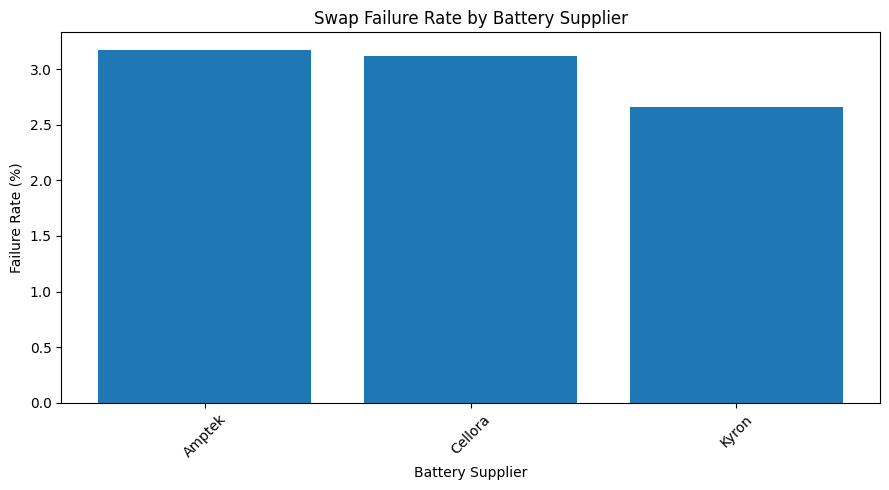

In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(
    supplier_performance['supplier'],
    supplier_performance['failure_rate_pct']
)

plt.title('Swap Failure Rate by Battery Supplier')
plt.xlabel('Battery Supplier')
plt.ylabel('Failure Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
lot_performance = (
    soh_analysis
    .groupby('manufacturing_lot')
    .agg(
        total_attempts=('event_id', 'count'),
        completed_swaps=('event_category', lambda x: (x == 'Completed').sum()),
        failed_attempts=('event_category', lambda x: (x == 'Failed').sum()),
        battery_failures=(
            'event_type',
            lambda x: (x == 'failed_no_charged_battery').sum()
        ),
        avg_soh=('current_soh_pct', 'mean')
    )
    .reset_index()
)

lot_performance['failure_rate_pct'] = (
    lot_performance['failed_attempts']
    / lot_performance['total_attempts']
    * 100
)

lot_performance['battery_failure_rate_pct'] = (
    lot_performance['battery_failures']
    / lot_performance['total_attempts']
    * 100
)

lot_performance = lot_performance.sort_values(
    'failure_rate_pct',
    ascending=False
)

display(lot_performance.round(2))

,manufacturing_lot,total_attempts,completed_swaps,failed_attempts,battery_failures,avg_soh,failure_rate_pct,battery_failure_rate_pct
54,KY-2418,3634,3262,244,244,86.49,6.71,6.71
52,KY-2416,5176,4687,331,331,86.73,6.39,6.39
50,KY-2414,4290,3879,267,267,86.46,6.22,6.22
46,KY-2410,4494,4092,274,274,86.25,6.10,6.10
47,KY-2411,5586,5081,339,339,86.56,6.07,6.07
51,KY-2415,6223,5653,372,372,86.55,5.98,5.98
53,KY-2417,5270,4816,315,315,86.58,5.98,5.98
48,KY-2412,5479,4963,322,322,86.45,5.88,5.88
49,KY-2413,6469,5905,357,357,86.64,5.52,5.52
0,AM-2403,33791,32105,1166,1166,80.93,3.45,3.45


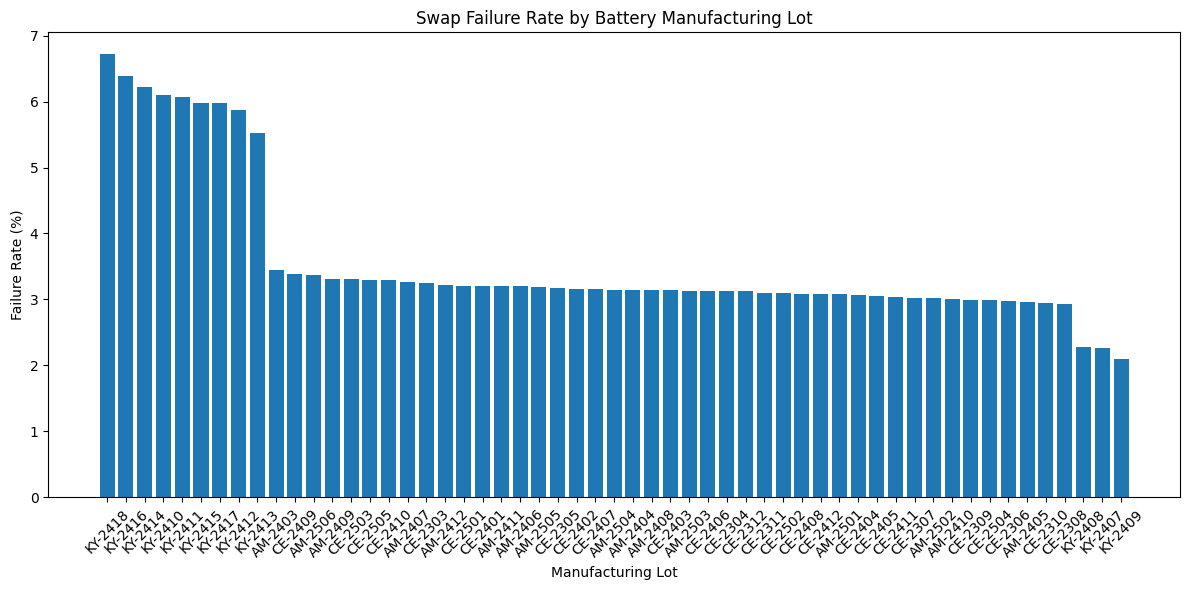

In [ ]:
plt.figure(figsize=(12, 6))

plt.bar(
    lot_performance['manufacturing_lot'].astype(str),
    lot_performance['failure_rate_pct']
)

plt.title('Swap Failure Rate by Battery Manufacturing Lot')
plt.xlabel('Manufacturing Lot')
plt.ylabel('Failure Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
print(stations.columns.tolist())
display(stations.head())

['station_id', 'city', 'zone', 'latitude', 'longitude', 'location_type', 'host_type', 'commissioned_date', 'decommissioned_date', 'expansion_wave', 'charger_generation', 'slots_2w', 'slots_3w', 'inventory_target_2w', 'inventory_target_3w', 'monthly_rent_inr', 'monthly_maintenance_inr', 'grid_tariff_inr_kwh', 'connectivity_tier', 'firmware_version', 'firmware_updated_date', 'competitor_within_1_5km_since']


,station_id,city,zone,latitude,longitude,location_type,host_type,commissioned_date,decommissioned_date,expansion_wave,charger_generation,slots_2w,slots_3w,inventory_target_2w,inventory_target_3w,monthly_rent_inr,monthly_maintenance_inr,grid_tariff_inr_kwh,connectivity_tier,firmware_version,firmware_updated_date,competitor_within_1_5km_since
0,STN-BLR-001,Bengaluru,BLR-Electronic City,12.926943,77.604655,transit_hub,mall_parking,2023-12-09,NaT,Launch,Gen1,12,6,32,7,23247,5436,9.29,good,v3.2.1,2025-04-14,NaN
1,STN-BLR-002,Bengaluru,BLR-Central,13.149199,77.530565,commercial_hub,kirana,2023-06-20,NaT,Launch,Gen2,16,0,38,0,23201,5249,8.41,poor,v3.2.1,2025-04-14,NaN
2,STN-BLR-003,Bengaluru,BLR-Electronic City,12.917986,77.607560,commercial_hub,fuel_retailer,2023-09-26,NaT,Launch,Gen2,16,0,43,0,10281,4516,8.66,good,v3.2.1,2025-04-14,NaN
3,STN-BLR-004,Bengaluru,BLR-Whitefield,13.030901,77.489397,market,mall_parking,2023-08-25,NaT,Launch,Gen1,16,0,33,0,12322,5802,9.19,good,v3.2.1,2025-04-14,NaN
4,STN-BLR-005,Bengaluru,BLR-North,12.815864,77.628712,residential,mall_parking,2023-11-07,NaT,Launch,Gen1,12,0,15,0,24194,7134,8.68,fair,v3.2.1,2025-04-14,NaN


In [ ]:
station_analysis = swap_events_clean.merge(
    stations[['station_id', 'city', 'location_type', 'charger_generation',
              'commissioned_date', 'connectivity_tier']],
    on='station_id',
    how='left'
)

charger_performance = (
    station_analysis
    .groupby('charger_generation')
    .agg(
        total_attempts=('event_id', 'count'),
        completed_swaps=('event_category', lambda x: (x == 'Completed').sum()),
        failed_attempts=('event_category', lambda x: (x == 'Failed').sum()),
        abandoned_attempts=('event_category', lambda x: (x == 'Abandoned').sum())
    )
    .reset_index()
)

charger_performance['failure_rate_pct'] = (
    charger_performance['failed_attempts']
    / charger_performance['total_attempts']
    * 100
)

charger_performance['abandonment_rate_pct'] = (
    charger_performance['abandoned_attempts']
    / charger_performance['total_attempts']
    * 100
)

display(charger_performance.round(2))

,charger_generation,total_attempts,completed_swaps,failed_attempts,abandoned_attempts,failure_rate_pct,abandonment_rate_pct
0,Gen1,1224390,1150252,46729,22159,3.82,1.81
1,Gen2,1072344,1023092,30314,14380,2.83,1.34
2,Gen3,62508,59864,1614,759,2.58,1.21


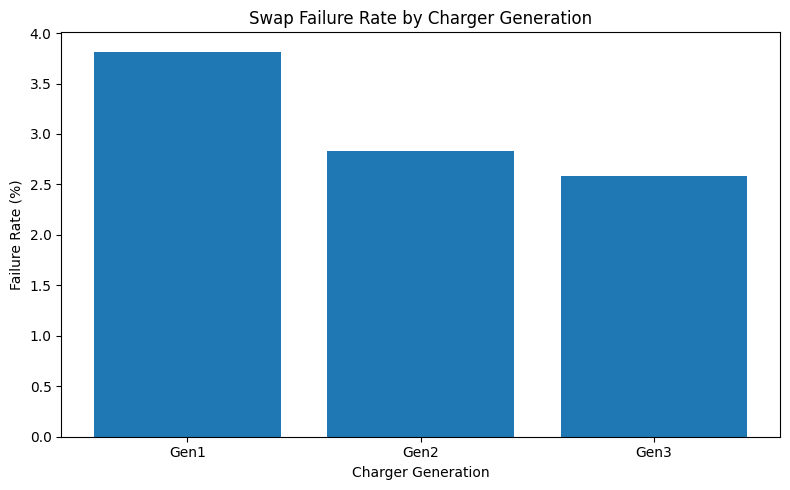

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    charger_performance['charger_generation'],
    charger_performance['failure_rate_pct']
)

plt.title('Swap Failure Rate by Charger Generation')
plt.xlabel('Charger Generation')
plt.ylabel('Failure Rate (%)')
plt.tight_layout()
plt.show()

In [ ]:
location_performance = (
    station_analysis
    .groupby('location_type')
    .agg(
        total_attempts=('event_id', 'count'),
        completed_swaps=('event_category', lambda x: (x == 'Completed').sum()),
        failed_attempts=('event_category', lambda x: (x == 'Failed').sum()),
        abandoned_attempts=('event_category', lambda x: (x == 'Abandoned').sum())
    )
    .reset_index()
)

location_performance['failure_rate_pct'] = (
    location_performance['failed_attempts']
    / location_performance['total_attempts']
    * 100
)

location_performance['abandonment_rate_pct'] = (
    location_performance['abandoned_attempts']
    / location_performance['total_attempts']
    * 100
)

display(
    location_performance
    .sort_values('failure_rate_pct', ascending=False)
    .round(2)
)

,location_type,total_attempts,completed_swaps,failed_attempts,abandoned_attempts,failure_rate_pct,abandonment_rate_pct
2,market,770616,727842,26767,12683,3.47,1.65
5,transit_hub,105534,99810,3586,1690,3.40,1.60
0,commercial_hub,1032863,976990,34849,16635,3.37,1.61
4,tech_park,90460,85950,2820,1307,3.12,1.44
3,residential,216081,205384,6663,3099,3.08,1.43
1,highway_fuel_pump,143688,137232,3972,1884,2.76,1.31


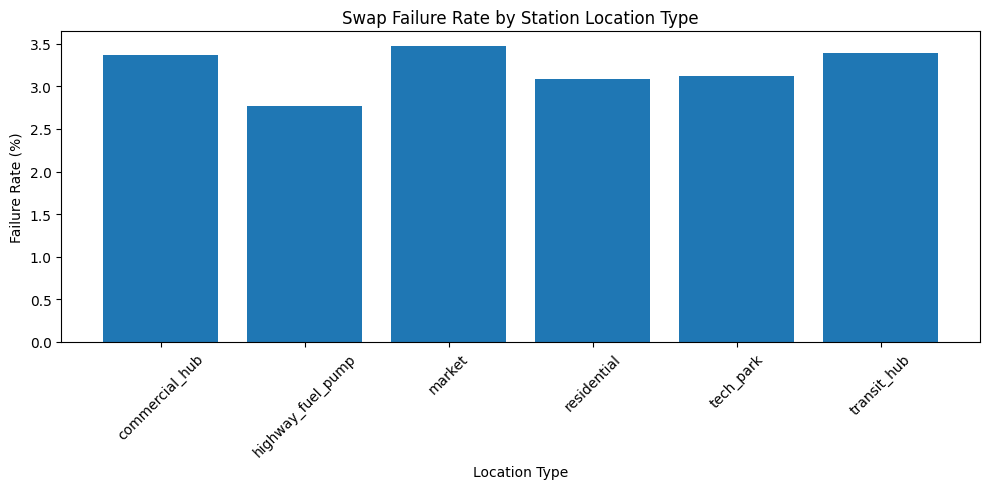

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    location_performance['location_type'],
    location_performance['failure_rate_pct']
)

plt.title('Swap Failure Rate by Station Location Type')
plt.xlabel('Location Type')
plt.ylabel('Failure Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
station_analysis['station_age_days'] = (
    station_analysis['event_ts'] - station_analysis['commissioned_date']
).dt.days

station_analysis['station_age_group'] = pd.cut(
    station_analysis['station_age_days'],
    bins=[-1, 180, 365, 730, 2000],
    labels=[
        'Less than 6 months',
        '6–12 months',
        '1–2 years',
        'More than 2 years'
    ]
)

age_performance = (
    station_analysis
    .groupby('station_age_group', observed=True)
    .agg(
        total_attempts=('event_id', 'count'),
        completed_swaps=('event_category', lambda x: (x == 'Completed').sum()),
        failed_attempts=('event_category', lambda x: (x == 'Failed').sum()),
        abandoned_attempts=('event_category', lambda x: (x == 'Abandoned').sum())
    )
    .reset_index()
)

age_performance['failure_rate_pct'] = (
    age_performance['failed_attempts']
    / age_performance['total_attempts']
    * 100
)

age_performance['abandonment_rate_pct'] = (
    age_performance['abandoned_attempts']
    / age_performance['total_attempts']
    * 100
)

display(age_performance.round(2))

,station_age_group,total_attempts,completed_swaps,failed_attempts,abandoned_attempts,failure_rate_pct,abandonment_rate_pct
0,Less than 6 months,529027,503850,15614,7271,2.95,1.37
1,6–12 months,884314,825461,37410,17666,4.23,2.00
2,1–2 years,945901,903897,25633,12361,2.71,1.31


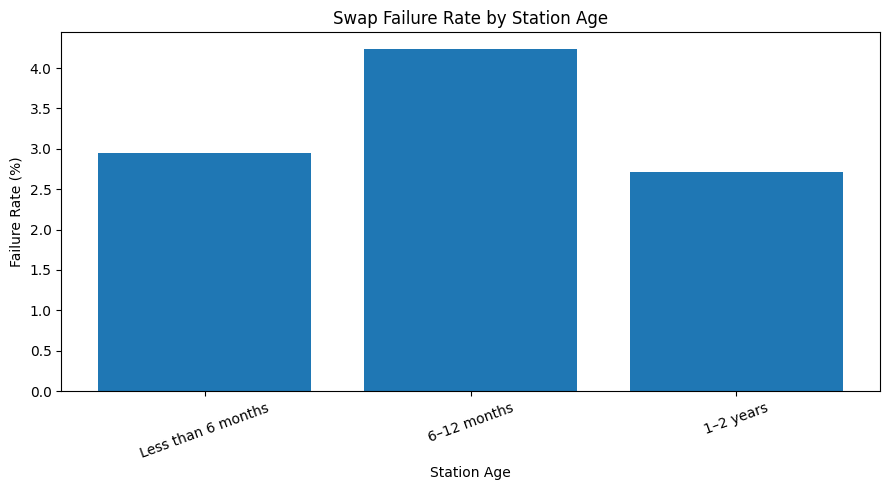

In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(
    age_performance['station_age_group'].astype(str),
    age_performance['failure_rate_pct']
)

plt.title('Swap Failure Rate by Station Age')
plt.xlabel('Station Age')
plt.ylabel('Failure Rate (%)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [ ]:
pricing_analysis = swap_events_clean[
    swap_events_clean['event_type'] == 'swap_completed'
].copy()

tariff_performance = (
    pricing_analysis
    .groupby('tariff_code')
    .agg(
        completed_swaps=('event_id', 'count'),
        avg_list_price_inr=('list_price_inr', 'mean'),
        avg_discount_inr=('discount_inr', 'mean'),
        avg_amount_charged_inr=('amount_charged_inr', 'mean'),
        total_revenue_inr=('amount_charged_inr', 'sum')
    )
    .reset_index()
)

display(tariff_performance.round(2))

,tariff_code,completed_swaps,avg_list_price_inr,avg_discount_inr,avg_amount_charged_inr,total_revenue_inr
0,OFFPEAK,14852,67.40,0.00,59.41,882304.0
1,PARTNER,1479809,69.05,8.12,61.50,91003685.7
2,PEAK,69927,67.47,0.00,82.47,5766955.0
3,STD,668620,65.59,0.00,65.59,43852630.0


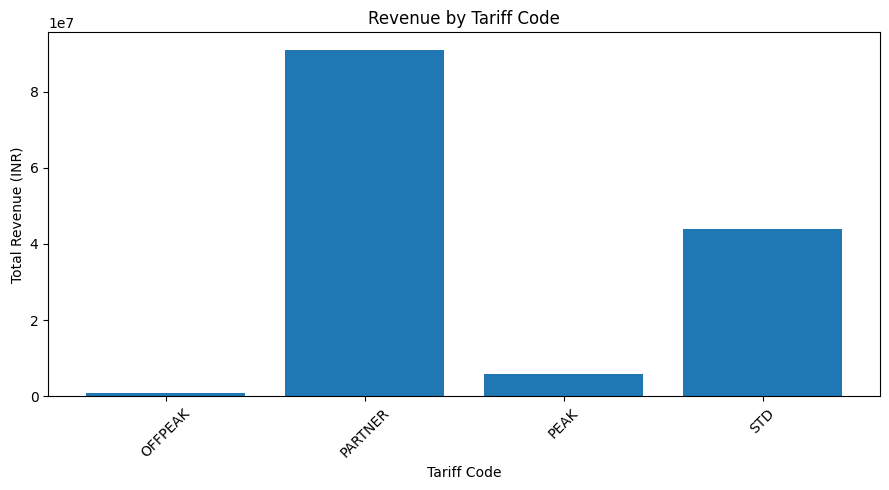

In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(
    tariff_performance['tariff_code'].astype(str),
    tariff_performance['total_revenue_inr']
)

plt.title('Revenue by Tariff Code')
plt.xlabel('Tariff Code')
plt.ylabel('Total Revenue (INR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
discount_analysis = (
    pricing_analysis
    .groupby('tariff_code')
    .agg(
        completed_swaps=('event_id', 'count'),
        avg_list_price_inr=('list_price_inr', 'mean'),
        avg_discount_inr=('discount_inr', 'mean'),
        avg_amount_charged_inr=('amount_charged_inr', 'mean'),
        total_discount_inr=('discount_inr', 'sum'),
        total_revenue_inr=('amount_charged_inr', 'sum')
    )
    .reset_index()
)

discount_analysis['realized_price_pct'] = (
    discount_analysis['avg_amount_charged_inr']
    / discount_analysis['avg_list_price_inr']
    * 100
)

display(discount_analysis.round(2))

,tariff_code,completed_swaps,avg_list_price_inr,avg_discount_inr,avg_amount_charged_inr,total_discount_inr,total_revenue_inr,realized_price_pct
0,OFFPEAK,14852,67.40,0.00,59.41,0.0,882304.0,88.14
1,PARTNER,1479809,69.05,8.12,61.50,12019365.3,91003685.7,89.06
2,PEAK,69927,67.47,0.00,82.47,0.0,5766955.0,122.23
3,STD,668620,65.59,0.00,65.59,0.0,43852630.0,100.00


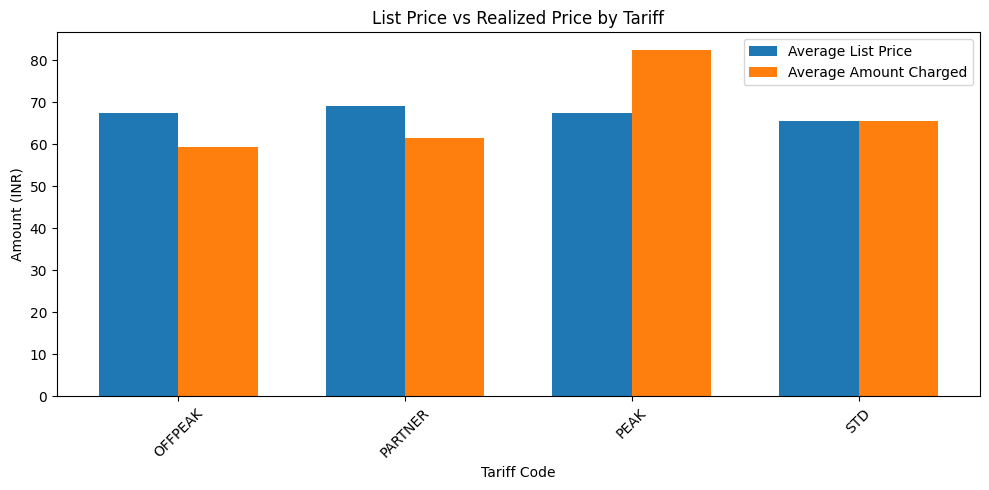

In [ ]:
plt.figure(figsize=(10, 5))

x = np.arange(len(discount_analysis))
width = 0.35

plt.bar(
    x - width/2,
    discount_analysis['avg_list_price_inr'],
    width,
    label='Average List Price'
)

plt.bar(
    x + width/2,
    discount_analysis['avg_amount_charged_inr'],
    width,
    label='Average Amount Charged'
)

plt.xticks(
    x,
    discount_analysis['tariff_code'].astype(str),
    rotation=45
)

plt.title('List Price vs Realized Price by Tariff')
plt.xlabel('Tariff Code')
plt.ylabel('Amount (INR)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
pricing_analysis['month'] = pricing_analysis['event_ts'].dt.to_period('M').astype(str)

monthly_pricing = (
    pricing_analysis
    .groupby('month')
    .agg(
        completed_swaps=('event_id', 'count'),
        avg_list_price_inr=('list_price_inr', 'mean'),
        avg_discount_inr=('discount_inr', 'mean'),
        avg_amount_charged_inr=('amount_charged_inr', 'mean'),
        total_revenue_inr=('amount_charged_inr', 'sum')
    )
    .reset_index()
)

display(monthly_pricing.round(2))

,month,completed_swaps,avg_list_price_inr,avg_discount_inr,avg_amount_charged_inr,total_revenue_inr
0,2024-01,105490,64.48,4.58,59.90,6318995.20
1,2024-02,106582,64.52,4.59,59.93,6387614.80
2,2024-03,118444,64.45,4.56,59.89,7093617.00
3,2024-04,122836,64.53,4.53,60.00,7370255.80
4,2024-05,128328,64.44,4.51,59.92,7689594.00
5,2024-06,133743,64.33,4.49,59.84,8003275.60
6,2024-07,151824,69.94,4.86,65.07,9879524.60
7,2024-08,164931,69.91,4.88,65.02,10724296.65
8,2024-09,187302,69.56,4.88,64.68,12115209.50
9,2024-10,219838,69.48,4.91,66.31,14577271.65


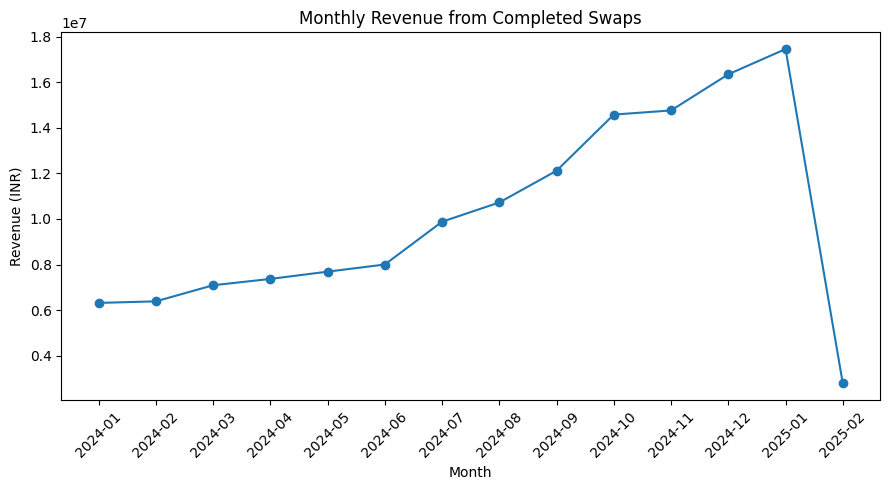

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    monthly_pricing['month'],
    monthly_pricing['total_revenue_inr'],
    marker='o'
)

plt.title('Monthly Revenue from Completed Swaps')
plt.xlabel('Month')
plt.ylabel('Revenue (INR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
print(fleet_partners.columns.tolist())
display(fleet_partners.head())

['partner_id', 'partner_name', 'partner_segment', 'vehicle_class', 'contract_type', 'contract_start_date', 'discount_pct', 'amendment_date', 'discount_pct_after_amendment', 'peak_surcharge_billable', 'payment_terms_days', 'cities_active']


,partner_id,partner_name,partner_segment,vehicle_class,contract_type,contract_start_date,discount_pct,amendment_date,discount_pct_after_amendment,peak_surcharge_billable,payment_terms_days,cities_active
0,FP-01,FeastFly,food_delivery,2W,volume_tiered,2023-04-01,10.0,NaT,NaN,Y,30,BLR|DEL|HYD|PUN|MUM|JAI
1,FP-02,ParcelNest,ecom_logistics,2W,pay_per_swap,2023-07-01,15.0,NaT,NaN,Y,30,BLR|DEL|HYD|MUM
2,FP-03,ZipDrop,quick_commerce,2W,volume_tiered,2023-06-01,12.0,2024-11-01,28.0,N,45,BLR|DEL|HYD|PUN|MUM|JAI
3,FP-04,CargoTuk,cargo_3w,3W,pay_per_swap,2023-09-01,8.0,NaT,NaN,Y,30,DEL|HYD|JAI
4,FP-05,Swiggle Go,food_delivery,2W,volume_tiered,2023-05-01,11.0,NaT,NaN,N,30,BLR|PUN|MUM


In [ ]:
partner_analysis = fleet_partners.copy()

partner_analysis['effective_discount_pct'] = np.where(
    partner_analysis['discount_pct_after_amendment'].notna(),
    partner_analysis['discount_pct_after_amendment'],
    partner_analysis['discount_pct']
)

display(
    partner_analysis[
        [
            'partner_id',
            'partner_name',
            'partner_segment',
            'vehicle_class',
            'contract_type',
            'effective_discount_pct',
            'peak_surcharge_billable',
            'payment_terms_days',
            'cities_active'
        ]
    ].sort_values('effective_discount_pct', ascending=False)
)

,partner_id,partner_name,partner_segment,vehicle_class,contract_type,effective_discount_pct,peak_surcharge_billable,payment_terms_days,cities_active
2,FP-03,ZipDrop,quick_commerce,2W,volume_tiered,28.0,N,45,BLR|DEL|HYD|PUN|MUM|JAI
1,FP-02,ParcelNest,ecom_logistics,2W,pay_per_swap,15.0,Y,30,BLR|DEL|HYD|MUM
9,FP-10,MetroMove,ecom_logistics,mixed,volume_tiered,12.0,Y,30,BLR|MUM
4,FP-05,Swiggle Go,food_delivery,2W,volume_tiered,11.0,N,30,BLR|PUN|MUM
10,FP-11,LastMileHub,ecom_logistics,2W,pay_per_swap,10.0,Y,30,HYD|PUN
0,FP-01,FeastFly,food_delivery,2W,volume_tiered,10.0,Y,30,BLR|DEL|HYD|PUN|MUM|JAI
6,FP-07,QuickCart,quick_commerce,2W,pay_per_swap,9.0,Y,30,DEL|HYD
3,FP-04,CargoTuk,cargo_3w,3W,pay_per_swap,8.0,Y,30,DEL|HYD|JAI
7,FP-08,DabbaXpress,food_delivery,2W,pay_per_swap,8.0,Y,30,PUN|MUM
8,FP-09,HaulKing,cargo_3w,3W,pay_per_swap,7.0,Y,45,JAI|DEL


In [ ]:
contract_performance = (
    partner_analysis
    .groupby('contract_type')
    .agg(
        partners=('partner_id', 'count'),
        avg_discount_pct=('effective_discount_pct', 'mean'),
        avg_payment_terms_days=('payment_terms_days', 'mean')
    )
    .reset_index()
)

display(contract_performance.round(2))

,contract_type,partners,avg_discount_pct,avg_payment_terms_days
0,pay_per_swap,8,8.50,28.12
1,volume_tiered,4,15.25,33.75


In [ ]:
segment_performance = (
    partner_analysis
    .groupby('partner_segment')
    .agg(
        partners=('partner_id', 'count'),
        avg_discount_pct=('effective_discount_pct', 'mean'),
        avg_payment_terms_days=('payment_terms_days', 'mean')
    )
    .reset_index()
)

display(segment_performance.round(2))

,partner_segment,partners,avg_discount_pct,avg_payment_terms_days
0,bike_taxi,2,5.50,15.0
1,cargo_3w,2,7.50,37.5
2,ecom_logistics,3,12.33,30.0
3,food_delivery,3,9.67,30.0
4,quick_commerce,2,18.50,37.5


In [ ]:
pricing_analysis['hour'] = pricing_analysis['event_ts'].dt.hour

pricing_analysis['period'] = np.where(
    pricing_analysis['hour'].between(18, 22),
    'Peak',
    'Off-Peak'
)

peak_analysis = (
    pricing_analysis
    .groupby('period')
    .agg(
        completed_swaps=('event_id', 'count'),
        avg_list_price_inr=('list_price_inr', 'mean'),
        avg_discount_inr=('discount_inr', 'mean'),
        avg_amount_charged_inr=('amount_charged_inr', 'mean'),
        total_revenue_inr=('amount_charged_inr', 'sum')
    )
    .reset_index()
)

display(peak_analysis.round(2))

,period,completed_swaps,avg_list_price_inr,avg_discount_inr,avg_amount_charged_inr,total_revenue_inr
0,Off-Peak,1251444,69.15,5.74,63.72,79739763.2
1,Peak,981764,66.43,4.93,62.91,61765811.5


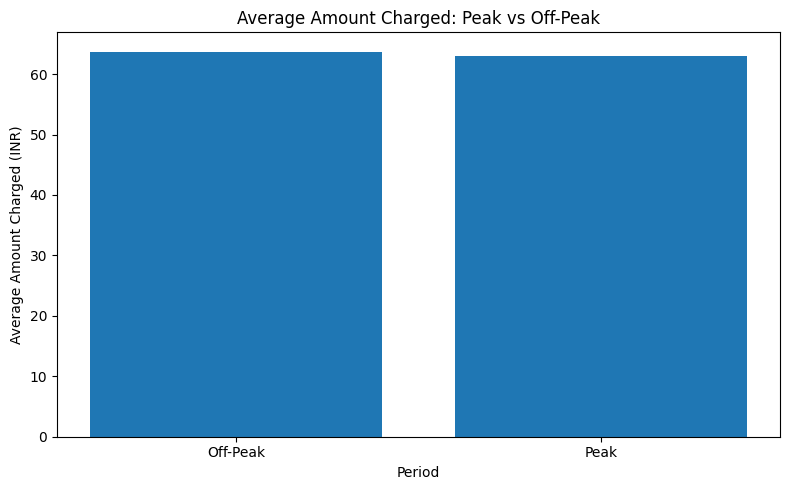

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    peak_analysis['period'],
    peak_analysis['avg_amount_charged_inr']
)

plt.title('Average Amount Charged: Peak vs Off-Peak')
plt.xlabel('Period')
plt.ylabel('Average Amount Charged (INR)')
plt.tight_layout()
plt.show()

In [ ]:
margin_data = swap_events_clean[
    swap_events_clean['event_type'] == 'swap_completed'
].merge(
    stations[
        [
            'station_id',
            'grid_tariff_inr_kwh',
            'monthly_rent_inr',
            'monthly_maintenance_inr'
        ]
    ],
    on='station_id',
    how='left'
)

margin_data['energy_cost_inr'] = (
    margin_data['energy_to_recharge_kwh']
    * margin_data['grid_tariff_inr_kwh']
)

margin_data['contribution_margin_inr'] = (
    margin_data['amount_charged_inr']
    - margin_data['energy_cost_inr']
)

margin_summary = pd.DataFrame({
    'Metric': [
        'Completed swaps',
        'Average amount charged',
        'Average energy cost',
        'Average contribution margin per swap',
        'Total revenue',
        'Total energy cost',
        'Total contribution margin'
    ],
    'Value': [
        len(margin_data),
        margin_data['amount_charged_inr'].mean(),
        margin_data['energy_cost_inr'].mean(),
        margin_data['contribution_margin_inr'].mean(),
        margin_data['amount_charged_inr'].sum(),
        margin_data['energy_cost_inr'].sum(),
        margin_data['contribution_margin_inr'].sum()
    ]
})

display(margin_summary.round(2))

,Metric,Value
0,Completed swaps,2.233208e+06
1,Average amount charged,6.336000e+01
2,Average energy cost,2.051000e+01
3,Average contribution margin per swap,4.285000e+01
4,Total revenue,1.415056e+08
5,Total energy cost,4.580242e+07
6,Total contribution margin,9.570310e+07


In [ ]:
margin_data['month'] = margin_data['event_ts'].dt.to_period('M').astype(str)

monthly_margin = (
    margin_data
    .groupby('month')
    .agg(
        completed_swaps=('event_id', 'count'),
        revenue_inr=('amount_charged_inr', 'sum'),
        energy_cost_inr=('energy_cost_inr', 'sum'),
        contribution_margin_inr=('contribution_margin_inr', 'sum'),
        avg_margin_per_swap_inr=('contribution_margin_inr', 'mean')
    )
    .reset_index()
)

display(monthly_margin.round(2))

,month,completed_swaps,revenue_inr,energy_cost_inr,contribution_margin_inr,avg_margin_per_swap_inr
0,2024-01,105490,6318995.20,2320971.24,3998023.96,37.90
1,2024-02,106582,6387614.80,2334290.44,4053324.36,38.03
2,2024-03,118444,7093617.00,2572346.56,4521270.44,38.17
3,2024-04,122836,7370255.80,2652598.93,4717656.87,38.41
4,2024-05,128328,7689594.00,2738029.26,4951564.74,38.59
5,2024-06,133743,8003275.60,2813405.94,5189869.66,38.80
6,2024-07,151824,9879524.60,3166309.81,6713214.79,44.22
7,2024-08,164931,10724296.65,3405336.13,7318960.52,44.38
8,2024-09,187302,12115209.50,3830745.92,8284463.58,44.23
9,2024-10,219838,14577271.65,4444666.63,10132605.02,46.09


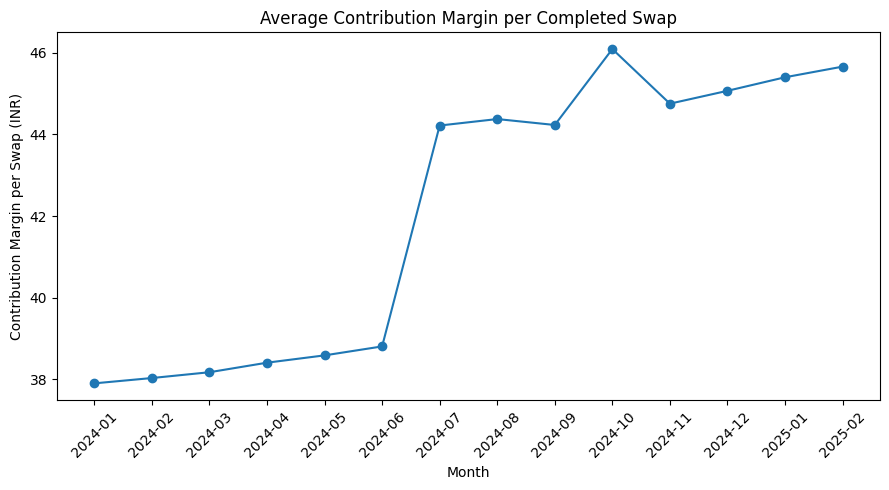

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    monthly_margin['month'],
    monthly_margin['avg_margin_per_swap_inr'],
    marker='o'
)

plt.title('Average Contribution Margin per Completed Swap')
plt.xlabel('Month')
plt.ylabel('Contribution Margin per Swap (INR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
rider_swaps = swap_events_clean[
    swap_events_clean['event_type'] == 'swap_completed'
].copy()

rider_activity = (
    rider_swaps
    .groupby('rider_id')
    .agg(
        first_swap=('event_ts', 'min'),
        last_swap=('event_ts', 'max'),
        total_swaps=('event_id', 'count')
    )
    .reset_index()
)

rider_activity['returned'] = np.where(
    rider_activity['total_swaps'] > 1,
    'Returned',
    'Did not return'
)

retention_summary = (
    rider_activity['returned']
    .value_counts()
    .reset_index()
)

retention_summary.columns = ['retention_status', 'rider_count']

retention_summary['percentage'] = (
    retention_summary['rider_count']
    / retention_summary['rider_count'].sum()
    * 100
)

display(retention_summary.round(2))

,retention_status,rider_count,percentage
0,Returned,14396,99.42
1,Did not return,84,0.58


In [ ]:
rider_experience = (
    swap_events_clean
    .groupby('rider_id')
    .agg(
        total_attempts=('event_id', 'count'),
        completed_swaps=('event_category', lambda x: (x == 'Completed').sum()),
        failed_attempts=('event_category', lambda x: (x == 'Failed').sum()),
        abandoned_attempts=('event_category', lambda x: (x == 'Abandoned').sum()),
        avg_queue_wait_sec=('queue_wait_sec', 'mean')
    )
    .reset_index()
)

rider_experience = rider_experience.merge(
    rider_activity[['rider_id', 'returned']],
    on='rider_id',
    how='left'
)

rider_experience['failure_rate_pct'] = (
    rider_experience['failed_attempts']
    / rider_experience['total_attempts']
    * 100
)

rider_experience['abandonment_rate_pct'] = (
    rider_experience['abandoned_attempts']
    / rider_experience['total_attempts']
    * 100
)

retention_experience = (
    rider_experience
    .groupby('returned')
    .agg(
        riders=('rider_id', 'count'),
        avg_attempts=('total_attempts', 'mean'),
        avg_queue_wait_sec=('avg_queue_wait_sec', 'mean'),
        avg_failure_rate_pct=('failure_rate_pct', 'mean'),
        avg_abandonment_rate_pct=('abandonment_rate_pct', 'mean')
    )
    .reset_index()
)

display(retention_experience.round(2))

,returned,riders,avg_attempts,avg_queue_wait_sec,avg_failure_rate_pct,avg_abandonment_rate_pct
0,Did not return,84,1.20,237.11,5.16,3.37
1,Returned,14396,163.87,242.86,3.39,1.61


In [ ]:
first_swap = (
    swap_events_clean[
        swap_events_clean['event_type'] == 'swap_completed'
    ]
    .sort_values(['rider_id', 'event_ts'])
    .groupby('rider_id')
    .first()
    .reset_index()
)

first_swap = first_swap[
    [
        'rider_id',
        'event_ts',
        'queue_wait_sec',
        'amount_charged_inr',
        'station_id'
    ]
]

first_swap = first_swap.merge(
    rider_activity[['rider_id', 'returned']],
    on='rider_id',
    how='left'
)

first_swap_summary = (
    first_swap
    .groupby('returned')
    .agg(
        riders=('rider_id', 'count'),
        avg_first_queue_wait_sec=('queue_wait_sec', 'mean'),
        avg_first_amount_charged_inr=('amount_charged_inr', 'mean')
    )
    .reset_index()
)

display(first_swap_summary.round(2))

,returned,riders,avg_first_queue_wait_sec,avg_first_amount_charged_inr
0,Did not return,84,243.98,71.68
1,Returned,14396,242.39,64.20


In [ ]:
first_swap_station = first_swap.merge(
    stations[
        [
            'station_id',
            'city',
            'location_type',
            'charger_generation',
            'connectivity_tier'
        ]
    ],
    on='station_id',
    how='left'
)

first_station_summary = (
    first_swap_station
    .groupby('returned')
    .agg(
        riders=('rider_id', 'count'),
        avg_first_queue_wait_sec=('queue_wait_sec', 'mean'),
        avg_first_amount_charged_inr=('amount_charged_inr', 'mean'),
        avg_station_connectivity=('connectivity_tier', 'count')
    )
    .reset_index()
)

display(first_station_summary.round(2))

,returned,riders,avg_first_queue_wait_sec,avg_first_amount_charged_inr,avg_station_connectivity
0,Did not return,84,243.98,71.68,84
1,Returned,14396,242.39,64.20,14396


In [ ]:
city_retention = (
    first_swap_station
    .groupby('city')
    .agg(
        first_time_riders=('rider_id', 'count'),
        returned_riders=('returned', lambda x: (x == 'Returned').sum())
    )
    .reset_index()
)

city_retention['return_rate_pct'] = (
    city_retention['returned_riders']
    / city_retention['first_time_riders']
    * 100
)

display(
    city_retention
    .sort_values('return_rate_pct', ascending=False)
    .round(2)
)

,city,first_time_riders,returned_riders,return_rate_pct
4,Mumbai,2081,2073,99.62
1,Delhi NCR,2794,2779,99.46
0,Bengaluru,3170,3152,99.43
2,Hyderabad,2522,2507,99.41
5,Pune,2122,2108,99.34
3,Jaipur,1791,1777,99.22


In [ ]:
print(support_tickets.columns.tolist())
display(support_tickets.head())

['ticket_id', 'rider_id', 'station_id', 'battery_id', 'created_ts', 'channel', 'category', 'rider_comment', 'priority', 'resolution_status', 'resolution_hours', 'csat_score']


,ticket_id,rider_id,station_id,battery_id,created_ts,channel,category,rider_comment,priority,resolution_status,resolution_hours,csat_score
0,TK-0000001,RD-1001097,STN-BLR-016,NaN,2024-01-01 17:44:05,call_center,billing_dispute,amount galat kata hai is baar,low,duplicate,NaN,NaN
1,TK-0000002,RD-1001216,STN-BLR-020,BAT-2W-104489,2024-01-01 22:59:14,partner_escalation,long_queue,queue itna lamba tha ki late ho gaya delivery ...,medium,resolved,5.2,NaN
2,TK-0000003,RD-1001631,STN-JAI-140,BAT-2W-102867,2024-01-01 19:20:12,app_chat,long_queue,queue itna lamba tha ki late ho gaya delivery ...,medium,resolved,16.3,NaN
3,TK-0000004,RD-1002086,STN-DEL-039,BAT-2W-102727,2024-01-01 03:14:33,partner_escalation,long_queue,queue itna lamba tha ki late ho gaya delivery ...,high,resolved,4.4,3.0
4,TK-0000005,RD-1002308,STN-BLR-004,BAT-2W-105975,2024-01-02 01:47:49,app_chat,other,scooter weak lag raha hai aajkal,low,resolved,23.3,1.0


In [ ]:
ticket_category = (
    support_tickets
    .groupby('category')
    .agg(
        ticket_count=('ticket_id', 'count'),
        avg_resolution_hours=('resolution_hours', 'mean'),
        avg_csat=('csat_score', 'mean')
    )
    .reset_index()
)

ticket_category['ticket_share_pct'] = (
    ticket_category['ticket_count']
    / ticket_category['ticket_count'].sum()
    * 100
)

ticket_category = ticket_category.sort_values(
    'ticket_count',
    ascending=False
)

display(ticket_category.round(2))

,category,ticket_count,avg_resolution_hours,avg_csat,ticket_share_pct
4,no_battery_available,11647,15.96,3.60,26.47
5,other,9484,16.04,3.57,21.55
3,low_range,6636,15.99,3.53,15.08
0,app_issue,5787,15.89,3.54,13.15
2,long_queue,5731,15.84,3.51,13.02
1,billing_dispute,4715,15.91,3.57,10.72


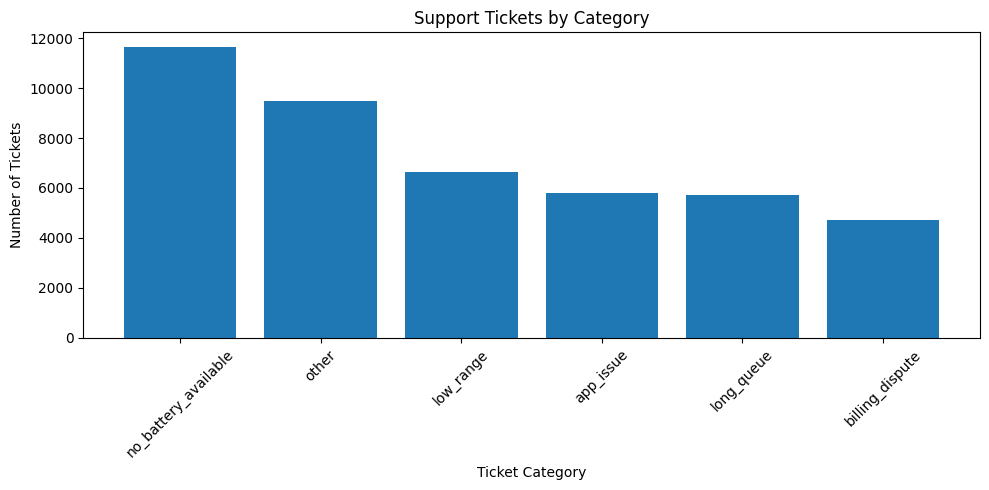

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    ticket_category['category'],
    ticket_category['ticket_count']
)

plt.title('Support Tickets by Category')
plt.xlabel('Ticket Category')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
csat_analysis = support_tickets.copy()

csat_summary = pd.DataFrame({
    'Metric': [
        'Total tickets',
        'Tickets with CSAT',
        'Tickets without CSAT',
        'CSAT availability %',
        'Average CSAT',
        'Average resolution time (hours)'
    ],
    'Value': [
        len(csat_analysis),
        csat_analysis['csat_score'].notna().sum(),
        csat_analysis['csat_score'].isna().sum(),
        csat_analysis['csat_score'].notna().mean() * 100,
        csat_analysis['csat_score'].mean(),
        csat_analysis['resolution_hours'].mean()
    ]
})

display(csat_summary.round(2))

,Metric,Value
0,Total tickets,44000.00
1,Tickets with CSAT,15129.00
2,Tickets without CSAT,28871.00
3,CSAT availability %,34.38
4,Average CSAT,3.56
5,Average resolution time (hours),15.95


In [ ]:
csat_by_category = (
    support_tickets
    .groupby('category')
    .agg(
        tickets=('ticket_id', 'count'),
        tickets_with_csat=('csat_score', 'count'),
        avg_csat=('csat_score', 'mean'),
        avg_resolution_hours=('resolution_hours', 'mean')
    )
    .reset_index()
)

csat_by_category['csat_response_rate_pct'] = (
    csat_by_category['tickets_with_csat']
    / csat_by_category['tickets']
    * 100
)

display(
    csat_by_category
    .sort_values('avg_csat', ascending=False)
    .round(2)
)

,category,tickets,tickets_with_csat,avg_csat,avg_resolution_hours,csat_response_rate_pct
4,no_battery_available,11647,3997,3.60,15.96,34.32
1,billing_dispute,4715,1620,3.57,15.91,34.36
5,other,9484,3246,3.57,16.04,34.23
0,app_issue,5787,1947,3.54,15.89,33.64
3,low_range,6636,2325,3.53,15.99,35.04
2,long_queue,5731,1994,3.51,15.84,34.79


In [ ]:
ticket_station = support_tickets.merge(
    stations[
        ['station_id', 'city', 'zone', 'location_type']
    ],
    on='station_id',
    how='left'
)

city_tickets = (
    ticket_station
    .groupby('city')
    .agg(
        total_tickets=('ticket_id', 'count'),
        avg_resolution_hours=('resolution_hours', 'mean'),
        avg_csat=('csat_score', 'mean')
    )
    .reset_index()
)

city_tickets['ticket_share_pct'] = (
    city_tickets['total_tickets']
    / city_tickets['total_tickets'].sum()
    * 100
)

display(
    city_tickets
    .sort_values('total_tickets', ascending=False)
    .round(2)
)

,city,total_tickets,avg_resolution_hours,avg_csat,ticket_share_pct
1,Delhi NCR,9907,16.06,3.56,23.72
2,Hyderabad,8594,15.84,3.55,20.57
0,Bengaluru,7187,15.81,3.57,17.20
3,Jaipur,6536,16.09,3.56,15.65
5,Pune,5032,16.07,3.57,12.05
4,Mumbai,4517,15.91,3.53,10.81


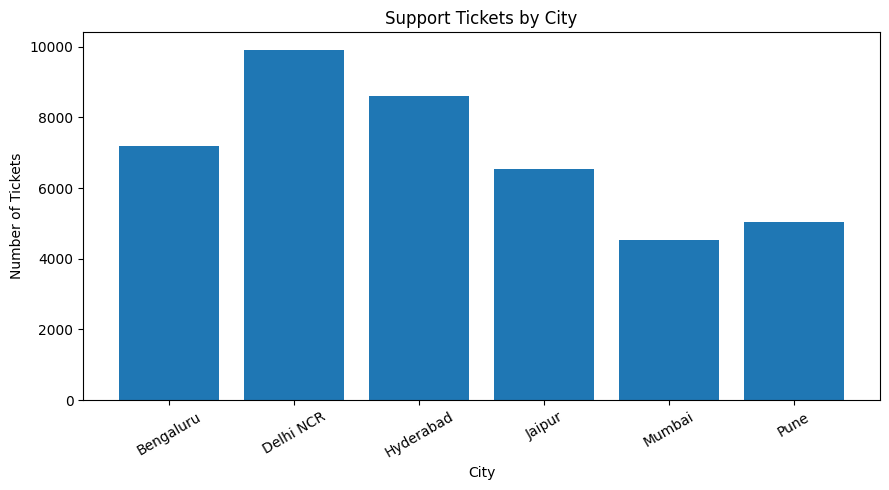

In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(
    city_tickets['city'],
    city_tickets['total_tickets']
)

plt.title('Support Tickets by City')
plt.xlabel('City')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
station_tickets = (
    ticket_station
    .groupby(['station_id', 'city'])
    .agg(
        total_tickets=('ticket_id', 'count'),
        avg_resolution_hours=('resolution_hours', 'mean'),
        avg_csat=('csat_score', 'mean')
    )
    .reset_index()
)

top_ticket_stations = (
    station_tickets
    .sort_values('total_tickets', ascending=False)
    .head(15)
)

display(top_ticket_stations.round(2))

,station_id,city,total_tickets,avg_resolution_hours,avg_csat
71,STN-HYD-072,Hyderabad,689,15.52,3.66
42,STN-DEL-043,Delhi NCR,681,16.46,3.50
93,STN-JAI-138,Jaipur,674,15.91,3.52
96,STN-JAI-141,Jaipur,645,16.95,3.49
49,STN-DEL-050,Delhi NCR,639,16.42,3.62
95,STN-JAI-140,Jaipur,626,16.23,3.53
69,STN-HYD-070,Hyderabad,618,15.65,3.41
92,STN-JAI-137,Jaipur,586,16.07,3.63
89,STN-JAI-134,Jaipur,584,15.99,3.47
64,STN-HYD-065,Hyderabad,551,15.68,3.62


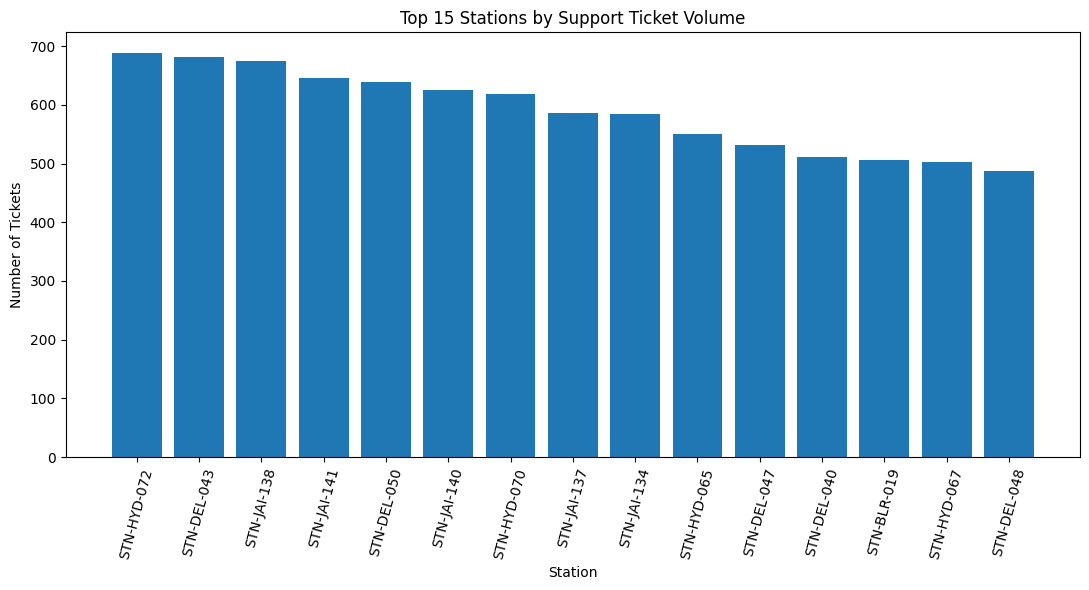

In [ ]:
plt.figure(figsize=(11, 6))

plt.bar(
    top_ticket_stations['station_id'],
    top_ticket_stations['total_tickets']
)

plt.title('Top 15 Stations by Support Ticket Volume')
plt.xlabel('Station')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [ ]:
station_operations = (
    swap_events_clean
    .groupby('station_id')
    .agg(
        total_attempts=('event_id', 'count'),
        failed_attempts=('event_category', lambda x: (x == 'Failed').sum()),
        abandoned_attempts=('event_category', lambda x: (x == 'Abandoned').sum())
    )
    .reset_index()
)

station_operations['failure_rate_pct'] = (
    station_operations['failed_attempts']
    / station_operations['total_attempts']
    * 100
)

station_complaints = (
    ticket_station
    .groupby('station_id')
    .agg(
        ticket_count=('ticket_id', 'count'),
        avg_resolution_hours=('resolution_hours', 'mean'),
        avg_csat=('csat_score', 'mean')
    )
    .reset_index()
)

station_comparison = station_operations.merge(
    station_complaints,
    on='station_id',
    how='left'
)

station_comparison['ticket_count'] = (
    station_comparison['ticket_count'].fillna(0)
)

display(
    station_comparison
    .sort_values('ticket_count', ascending=False)
    .head(15)
    .round(2)
)

,station_id,total_attempts,failed_attempts,abandoned_attempts,failure_rate_pct,ticket_count,avg_resolution_hours,avg_csat
59,STN-HYD-072,31677,1251,624,3.95,689,15.52,3.66
36,STN-DEL-043,31466,1298,634,4.13,681,16.46,3.50
77,STN-JAI-138,33865,1540,717,4.55,674,15.91,3.52
80,STN-JAI-141,30427,1293,628,4.25,645,16.95,3.49
43,STN-DEL-050,29251,1254,564,4.29,639,16.42,3.62
79,STN-JAI-140,30495,1339,600,4.39,626,16.23,3.53
57,STN-HYD-070,32397,1295,586,4.00,618,15.65,3.41
76,STN-JAI-137,29569,1305,627,4.41,586,16.07,3.63
73,STN-JAI-134,29525,1247,603,4.22,584,15.99,3.47
52,STN-HYD-065,30001,1105,521,3.68,551,15.68,3.62


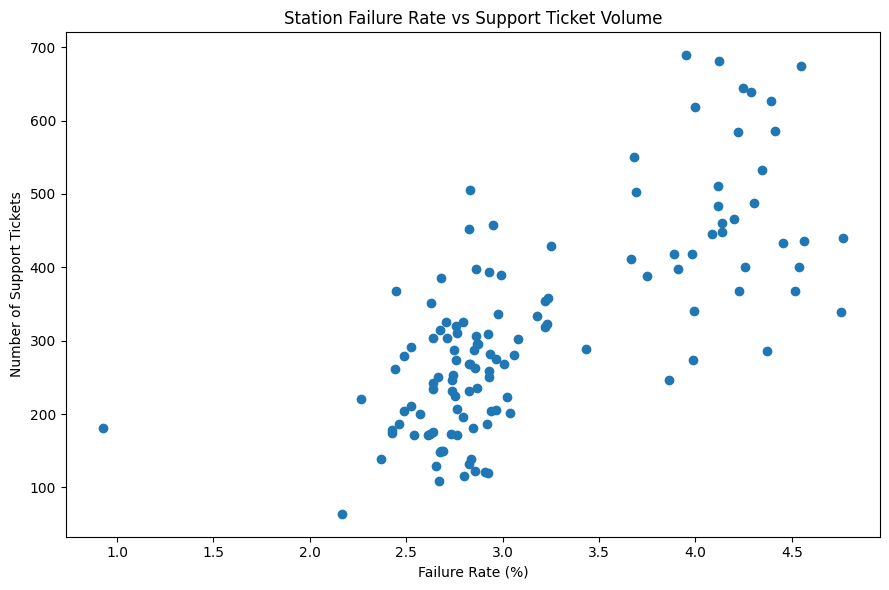

In [ ]:
plt.figure(figsize=(9, 6))

plt.scatter(
    station_comparison['failure_rate_pct'],
    station_comparison['ticket_count']
)

plt.title('Station Failure Rate vs Support Ticket Volume')
plt.xlabel('Failure Rate (%)')
plt.ylabel('Number of Support Tickets')
plt.tight_layout()
plt.show()

In [ ]:
print(city_context.columns.tolist())
display(city_context.head())

['city', 'date', 'max_temp_c', 'min_temp_c', 'rainfall_mm', 'heat_alert', 'flood_disruption', 'festival_or_event', 'is_public_holiday', 'grid_outage_hours', 'competitor_promo_active', 'ecommerce_sale_event']


,city,date,max_temp_c,min_temp_c,rainfall_mm,heat_alert,flood_disruption,festival_or_event,is_public_holiday,grid_outage_hours,competitor_promo_active,ecommerce_sale_event
0,Bengaluru,2024-01-01,16.7,6.7,0.0,False,False,NaN,False,0.0,False,False
1,Bengaluru,2024-01-02,17.3,4.6,1.8,False,False,NaN,False,0.2,False,False
2,Bengaluru,2024-01-03,13.9,6.9,0.7,False,False,NaN,False,0.0,False,False
3,Bengaluru,2024-01-04,17.9,4.0,2.2,False,False,NaN,False,0.1,False,False
4,Bengaluru,2024-01-05,16.0,7.8,2.0,False,False,NaN,False,0.0,False,False


In [ ]:
print(city_context.columns.tolist())
display(city_context.head())

['city', 'date', 'max_temp_c', 'min_temp_c', 'rainfall_mm', 'heat_alert', 'flood_disruption', 'festival_or_event', 'is_public_holiday', 'grid_outage_hours', 'competitor_promo_active', 'ecommerce_sale_event']


,city,date,max_temp_c,min_temp_c,rainfall_mm,heat_alert,flood_disruption,festival_or_event,is_public_holiday,grid_outage_hours,competitor_promo_active,ecommerce_sale_event
0,Bengaluru,2024-01-01,16.7,6.7,0.0,False,False,NaN,False,0.0,False,False
1,Bengaluru,2024-01-02,17.3,4.6,1.8,False,False,NaN,False,0.2,False,False
2,Bengaluru,2024-01-03,13.9,6.9,0.7,False,False,NaN,False,0.0,False,False
3,Bengaluru,2024-01-04,17.9,4.0,2.2,False,False,NaN,False,0.1,False,False
4,Bengaluru,2024-01-05,16.0,7.8,2.0,False,False,NaN,False,0.0,False,False


In [ ]:
swap_daily = swap_events_clean.copy()

swap_daily['date'] = swap_daily['event_ts'].dt.date

daily_performance = (
    swap_daily
    .groupby(['date', 'station_id'])
    .agg(
        total_attempts=('event_id', 'count'),
        failed_attempts=('event_category', lambda x: (x == 'Failed').sum()),
        completed_swaps=('event_category', lambda x: (x == 'Completed').sum())
    )
    .reset_index()
)

daily_performance['failure_rate_pct'] = (
    daily_performance['failed_attempts']
    / daily_performance['total_attempts']
    * 100
)

daily_performance = daily_performance.merge(
    stations[['station_id', 'city']],
    on='station_id',
    how='left'
)

daily_performance['date'] = pd.to_datetime(daily_performance['date'])

daily_context = daily_performance.merge(
    city_context,
    on=['city', 'date'],
    how='left'
)

display(daily_context.head())

,date,station_id,total_attempts,failed_attempts,completed_swaps,failure_rate_pct,city,max_temp_c,min_temp_c,rainfall_mm,heat_alert,flood_disruption,festival_or_event,is_public_holiday,grid_outage_hours,competitor_promo_active,ecommerce_sale_event
0,2024-01-01,STN-BLR-001,13,0,13,0.000000,Bengaluru,16.7,6.7,0.0,False,False,NaN,False,0.0,False,False
1,2024-01-01,STN-BLR-002,19,0,19,0.000000,Bengaluru,16.7,6.7,0.0,False,False,NaN,False,0.0,False,False
2,2024-01-01,STN-BLR-003,24,2,22,8.333333,Bengaluru,16.7,6.7,0.0,False,False,NaN,False,0.0,False,False
3,2024-01-01,STN-BLR-004,25,0,25,0.000000,Bengaluru,16.7,6.7,0.0,False,False,NaN,False,0.0,False,False
4,2024-01-01,STN-BLR-005,22,0,22,0.000000,Bengaluru,16.7,6.7,0.0,False,False,NaN,False,0.0,False,False


In [ ]:
disruption_analysis = (
    daily_context
    .groupby('flood_disruption')
    .agg(
        days=('date', 'nunique'),
        total_attempts=('total_attempts', 'sum'),
        avg_failure_rate_pct=('failure_rate_pct', 'mean'),
        avg_rainfall_mm=('rainfall_mm', 'mean'),
        avg_grid_outage_hours=('grid_outage_hours', 'mean')
    )
    .reset_index()
)

display(disruption_analysis.round(2))

,flood_disruption,days,total_attempts,avg_failure_rate_pct,avg_rainfall_mm,avg_grid_outage_hours
0,False,402,2357530,3.39,6.17,0.08
1,True,5,1712,2.92,104.44,0.42


In [ ]:
heat_analysis = (
    daily_context
    .groupby('heat_alert')
    .agg(
        days=('date', 'nunique'),
        total_attempts=('total_attempts', 'sum'),
        avg_failure_rate_pct=('failure_rate_pct', 'mean'),
        avg_max_temp_c=('max_temp_c', 'mean')
    )
    .reset_index()
)

display(heat_analysis.round(2))

,heat_alert,days,total_attempts,avg_failure_rate_pct,avg_max_temp_c
0,False,402,2305741,3.17,22.38
1,True,33,53501,12.00,44.97


In [ ]:
rainfall_analysis = pd.DataFrame({
    'condition': [
        'No Rain',
        'Light Rain',
        'Heavy Rain'
    ],
    'min_rainfall': [0, 2, 10],
    'max_rainfall': [2, 10, np.inf]
})

daily_context['rainfall_group'] = pd.cut(
    daily_context['rainfall_mm'].fillna(0),
    bins=[-0.01, 2, 10, np.inf],
    labels=['No Rain', 'Light Rain', 'Heavy Rain']
)

rainfall_summary = (
    daily_context
    .groupby('rainfall_group', observed=True)
    .agg(
        days=('date', 'nunique'),
        total_attempts=('total_attempts', 'sum'),
        avg_failure_rate_pct=('failure_rate_pct', 'mean'),
        avg_rainfall_mm=('rainfall_mm', 'mean')
    )
    .reset_index()
)

display(rainfall_summary.round(2))

,rainfall_group,days,total_attempts,avg_failure_rate_pct,avg_rainfall_mm
0,No Rain,357,1525534,3.40,0.29
1,Light Rain,274,437168,3.44,4.57
2,Heavy Rain,129,396540,3.33,31.30


In [ ]:
daily_context['grid_outage_group'] = np.where(
    daily_context['grid_outage_hours'] > 0,
    'Grid Outage',
    'No Grid Outage'
)

outage_summary = (
    daily_context
    .groupby('grid_outage_group')
    .agg(
        days=('date', 'nunique'),
        total_attempts=('total_attempts', 'sum'),
        avg_failure_rate_pct=('failure_rate_pct', 'mean'),
        avg_grid_outage_hours=('grid_outage_hours', 'mean')
    )
    .reset_index()
)

display(outage_summary.round(2))

,grid_outage_group,days,total_attempts,avg_failure_rate_pct,avg_grid_outage_hours
0,Grid Outage,399,1280494,3.61,0.15
1,No Grid Outage,387,1078748,3.14,0.00


In [ ]:
promo_analysis = (
    daily_context
    .groupby('competitor_promo_active')
    .agg(
        days=('date', 'nunique'),
        total_attempts=('total_attempts', 'sum'),
        completed_swaps=('completed_swaps', 'sum'),
        avg_failure_rate_pct=('failure_rate_pct', 'mean')
    )
    .reset_index()
)

display(promo_analysis.round(2))

,competitor_promo_active,days,total_attempts,completed_swaps,avg_failure_rate_pct
0,False,402,2343489,2218137,3.40
1,True,5,15753,15071,2.56


In [ ]:
sale_analysis = (
    daily_context
    .groupby('ecommerce_sale_event')
    .agg(
        days=('date', 'nunique'),
        total_attempts=('total_attempts', 'sum'),
        completed_swaps=('completed_swaps', 'sum'),
        avg_failure_rate_pct=('failure_rate_pct', 'mean')
    )
    .reset_index()
)

display(sale_analysis.round(2))

,ecommerce_sale_event,days,total_attempts,completed_swaps,avg_failure_rate_pct
0,False,392,2287642,2164794,3.41
1,True,10,71600,68414,2.67


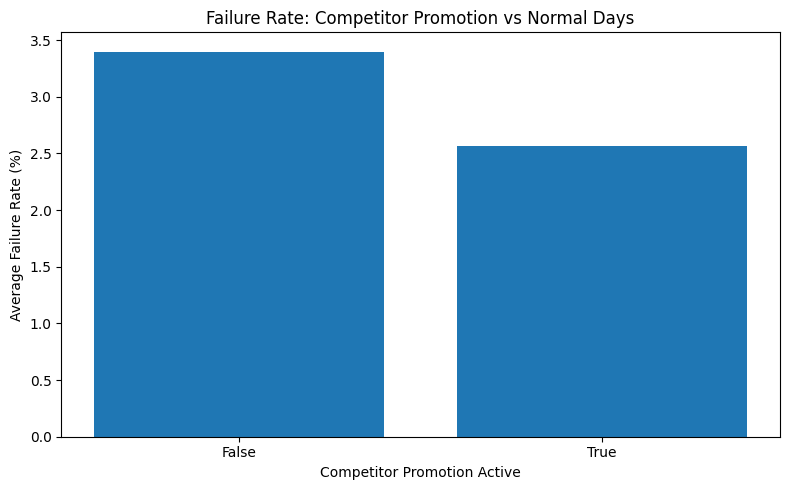

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    promo_analysis['competitor_promo_active'].astype(str),
    promo_analysis['avg_failure_rate_pct']
)

plt.title('Failure Rate: Competitor Promotion vs Normal Days')
plt.xlabel('Competitor Promotion Active')
plt.ylabel('Average Failure Rate (%)')
plt.tight_layout()
plt.show()

In [ ]:
station_operations = (
    swap_events_clean
    .groupby('station_id')
    .agg(
        total_attempts=('event_id', 'count'),
        completed_swaps=('event_category', lambda x: (x == 'Completed').sum()),
        failed_attempts=('event_category', lambda x: (x == 'Failed').sum()),
        abandoned_attempts=('event_category', lambda x: (x == 'Abandoned').sum())
    )
    .reset_index()
)

station_operations['failure_rate_pct'] = (
    station_operations['failed_attempts']
    / station_operations['total_attempts']
    * 100
)

station_operations['abandonment_rate_pct'] = (
    station_operations['abandoned_attempts']
    / station_operations['total_attempts']
    * 100
)

station_complaints = (
    support_tickets
    .groupby('station_id')
    .agg(
        ticket_count=('ticket_id', 'count'),
        avg_resolution_hours=('resolution_hours', 'mean'),
        avg_csat=('csat_score', 'mean')
    )
    .reset_index()
)

station_health = station_operations.merge(
    station_complaints,
    on='station_id',
    how='left'
)

station_health = station_health.merge(
    stations[
        [
            'station_id',
            'city',
            'location_type',
            'charger_generation',
            'connectivity_tier'
        ]
    ],
    on='station_id',
    how='left'
)

station_health['ticket_count'] = station_health['ticket_count'].fillna(0)

display(
    station_health
    .sort_values('failure_rate_pct', ascending=False)
    .head(15)
    .round(2)
)

,station_id,total_attempts,completed_swaps,failed_attempts,abandoned_attempts,failure_rate_pct,abandonment_rate_pct,ticket_count,avg_resolution_hours,avg_csat,city,location_type,charger_generation,connectivity_tier
30,STN-DEL-037,19641,18205,936,415,4.77,2.11,440,16.07,3.50,Delhi NCR,commercial_hub,Gen1,good
72,STN-JAI-133,19586,18141,931,440,4.75,2.25,339,15.70,3.71,Jaipur,market,Gen1,good
81,STN-JAI-142,23676,21958,1080,541,4.56,2.29,436,15.61,3.67,Jaipur,commercial_hub,Gen1,poor
77,STN-JAI-138,33865,31463,1540,717,4.55,2.12,674,15.91,3.52,Jaipur,market,Gen1,poor
78,STN-JAI-139,23110,21468,1048,507,4.53,2.19,400,16.57,3.72,Jaipur,commercial_hub,Gen1,poor
75,STN-JAI-136,21132,19639,954,440,4.51,2.08,368,15.60,3.53,Jaipur,transit_hub,Gen1,good
32,STN-DEL-039,21798,20273,971,449,4.45,2.06,433,16.21,3.64,Delhi NCR,residential,Gen1,fair
76,STN-JAI-137,29569,27505,1305,627,4.41,2.12,586,16.07,3.63,Jaipur,commercial_hub,Gen1,fair
79,STN-JAI-140,30495,28430,1339,600,4.39,1.97,626,16.23,3.53,Jaipur,commercial_hub,Gen1,fair
42,STN-DEL-049,15838,14771,692,313,4.37,1.98,286,15.47,3.47,Delhi NCR,tech_park,Gen1,fair


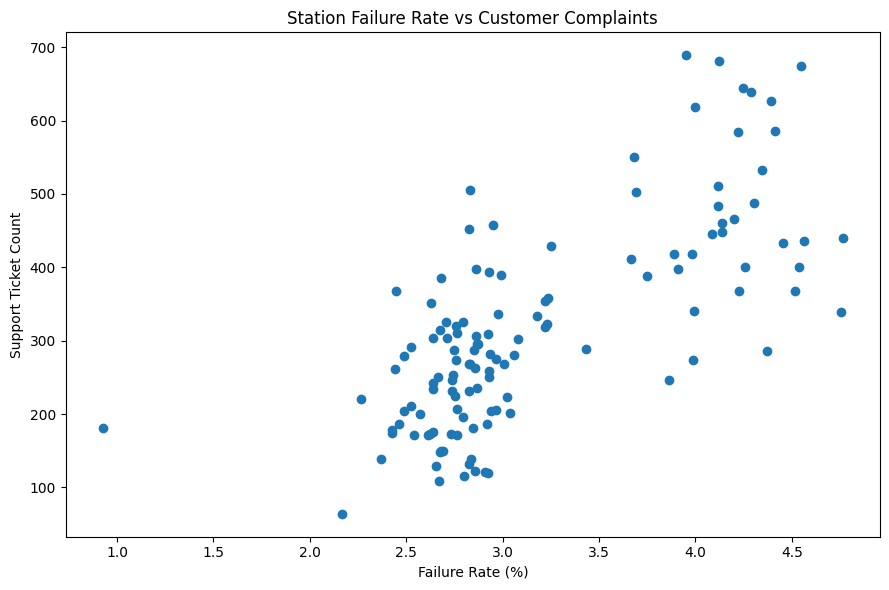

In [ ]:
plt.figure(figsize=(9, 6))

plt.scatter(
    station_health['failure_rate_pct'],
    station_health['ticket_count']
)

plt.xlabel('Failure Rate (%)')
plt.ylabel('Support Ticket Count')
plt.title('Station Failure Rate vs Customer Complaints')
plt.tight_layout()
plt.show()

In [ ]:
test_stations = stations[
    stations['station_id'].str.contains('STN-TST', na=False)
]

print("Number of test stations:", len(test_stations))

display(
    test_stations[
        ['station_id', 'city', 'location_type', 'host_type',
         'charger_generation', 'commissioned_date']
    ]
)

Number of test stations: 2


,station_id,city,location_type,host_type,charger_generation,commissioned_date
150,STN-TST-01,Bengaluru,commercial_hub,owned_lot,Gen2,2023-06-01
151,STN-TST-02,Bengaluru,commercial_hub,owned_lot,Gen2,2023-06-01


In [ ]:
test_station_events = swap_events_clean[
    swap_events_clean['station_id'].isin(test_stations['station_id'])
]

print("Events at test stations:", len(test_station_events))

display(
    test_station_events['event_type']
    .value_counts()
)

Events at test stations: 41545


,count
event_type,
swap_completed,39615
failed_no_charged_battery,1066
abandoned_queue,576
cancelled_by_rider,171
failed_system_error,117


In [ ]:
network_all = swap_events_clean.copy()

network_without_test = swap_events_clean[
    ~swap_events_clean['station_id'].isin(test_stations['station_id'])
].copy()

def network_summary(data, name):
    attempts = len(data)
    completed = (data['event_type'] == 'swap_completed').sum()
    failed = data['event_type'].isin([
        'failed_no_charged_battery',
        'failed_system_error'
    ]).sum()

    return {
        'Dataset': name,
        'Total Attempts': attempts,
        'Completed Swaps': completed,
        'Failed Attempts': failed,
        'Failure Rate (%)': failed / attempts * 100
    }

test_comparison = pd.DataFrame([
    network_summary(network_all, 'Including Test Stations'),
    network_summary(network_without_test, 'Excluding Test Stations')
])

display(test_comparison.round(2))

,Dataset,Total Attempts,Completed Swaps,Failed Attempts,Failure Rate (%)
0,Including Test Stations,2359242,2233208,78657,3.33
1,Excluding Test Stations,2317697,2193593,77474,3.34


In [ ]:
final_data = network_without_test.copy()

total_attempts = len(final_data)

completed_swaps = (
    final_data['event_type'] == 'swap_completed'
).sum()

failed_attempts = final_data['event_type'].isin([
    'failed_no_charged_battery',
    'failed_system_error'
]).sum()

abandoned_attempts = (
    final_data['event_type'] == 'abandoned_queue'
).sum()

cancelled_attempts = (
    final_data['event_type'] == 'cancelled_by_rider'
).sum()

revenue = final_data.loc[
    final_data['event_type'] == 'swap_completed',
    'amount_charged_inr'
].sum()

failure_rate = failed_attempts / total_attempts * 100

abandonment_rate = abandoned_attempts / total_attempts * 100

kpi_summary = pd.DataFrame({
    'Metric': [
        'Total Attempts',
        'Completed Swaps',
        'Failed Attempts',
        'Abandoned Attempts',
        'Cancelled Attempts',
        'Failure Rate (%)',
        'Abandonment Rate (%)',
        'Total Revenue (INR)'
    ],
    'Value': [
        total_attempts,
        completed_swaps,
        failed_attempts,
        abandoned_attempts,
        cancelled_attempts,
        failure_rate,
        abandonment_rate,
        revenue
    ]
})

display(kpi_summary.round(2))

,Metric,Value
0,Total Attempts,2.317697e+06
1,Completed Swaps,2.193593e+06
2,Failed Attempts,7.747400e+04
3,Abandoned Attempts,3.672200e+04
4,Cancelled Attempts,9.908000e+03
5,Failure Rate (%),3.340000e+00
6,Abandonment Rate (%),1.580000e+00
7,Total Revenue (INR),1.389192e+08


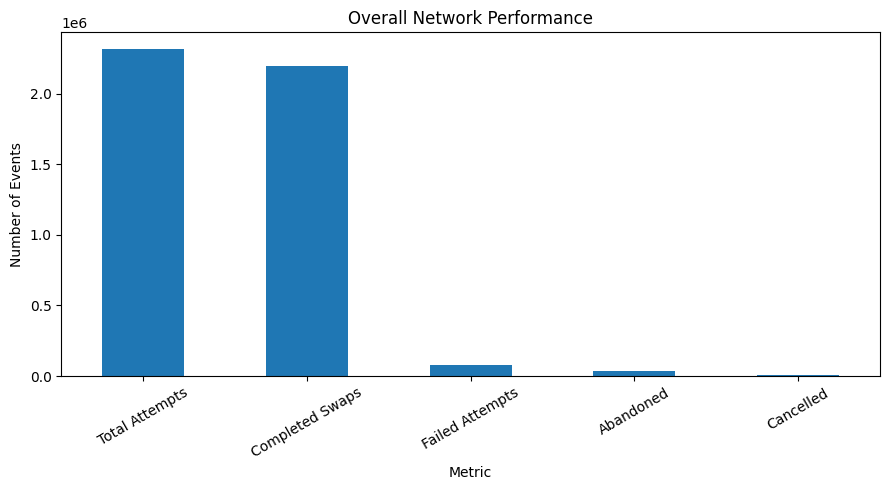

In [ ]:
kpi_chart = pd.Series({
    'Total Attempts': total_attempts,
    'Completed Swaps': completed_swaps,
    'Failed Attempts': failed_attempts,
    'Abandoned': abandoned_attempts,
    'Cancelled': cancelled_attempts
})

plt.figure(figsize=(9, 5))

kpi_chart.plot(kind='bar')

plt.title('Overall Network Performance')
plt.xlabel('Metric')
plt.ylabel('Number of Events')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
margin_data = final_data[
    final_data['event_type'] == 'swap_completed'
].copy()

margin_data = margin_data.merge(
    stations[
        [
            'station_id',
            'grid_tariff_inr_kwh'
        ]
    ],
    on='station_id',
    how='left'
)

margin_data['energy_cost_inr'] = (
    margin_data['energy_to_recharge_kwh']
    * margin_data['grid_tariff_inr_kwh']
)

margin_data['contribution_margin_inr'] = (
    margin_data['amount_charged_inr']
    - margin_data['energy_cost_inr']
)

margin_summary = pd.DataFrame({
    'Metric': [
        'Completed Swaps',
        'Average Amount Charged (INR)',
        'Average Energy Cost (INR)',
        'Average Contribution Margin per Swap (INR)',
        'Total Revenue (INR)',
        'Total Energy Cost (INR)',
        'Total Contribution Margin (INR)'
    ],
    'Value': [
        len(margin_data),
        margin_data['amount_charged_inr'].mean(),
        margin_data['energy_cost_inr'].mean(),
        margin_data['contribution_margin_inr'].mean(),
        margin_data['amount_charged_inr'].sum(),
        margin_data['energy_cost_inr'].sum(),
        margin_data['contribution_margin_inr'].sum()
    ]
})

display(margin_summary.round(2))

,Metric,Value
0,Completed Swaps,2.193593e+06
1,Average Amount Charged (INR),6.333000e+01
2,Average Energy Cost (INR),2.051000e+01
3,Average Contribution Margin per Swap (INR),4.282000e+01
4,Total Revenue (INR),1.389192e+08
5,Total Energy Cost (INR),4.498778e+07
6,Total Contribution Margin (INR),9.393132e+07


In [ ]:
margin_data['month'] = margin_data['event_ts'].dt.to_period('M').astype(str)

monthly_margin = (
    margin_data
    .groupby('month')
    .agg(
        completed_swaps=('event_id', 'count'),
        revenue_inr=('amount_charged_inr', 'sum'),
        energy_cost_inr=('energy_cost_inr', 'sum'),
        contribution_margin_inr=('contribution_margin_inr', 'sum'),
        avg_margin_per_swap=('contribution_margin_inr', 'mean')
    )
    .reset_index()
)

display(monthly_margin.round(2))

,month,completed_swaps,revenue_inr,energy_cost_inr,contribution_margin_inr,avg_margin_per_swap
0,2024-01,103508,6198803.40,2277787.22,3921016.18,37.88
1,2024-02,104437,6256296.00,2287103.96,3969192.04,38.01
2,2024-03,116148,6952642.00,2522069.53,4430572.47,38.15
3,2024-04,120117,7204036.20,2593933.09,4610103.11,38.38
4,2024-05,125454,7513212.80,2676061.66,4837151.14,38.56
5,2024-06,130880,7827373.00,2752443.38,5074929.62,38.78
6,2024-07,148611,9666799.25,3099532.34,6567266.91,44.19
7,2024-08,161688,10509533.60,3338422.99,7171110.61,44.35
8,2024-09,184051,11903273.70,3765599.27,8137674.43,44.21
9,2024-10,216551,14348597.95,4379886.40,9968711.55,46.03


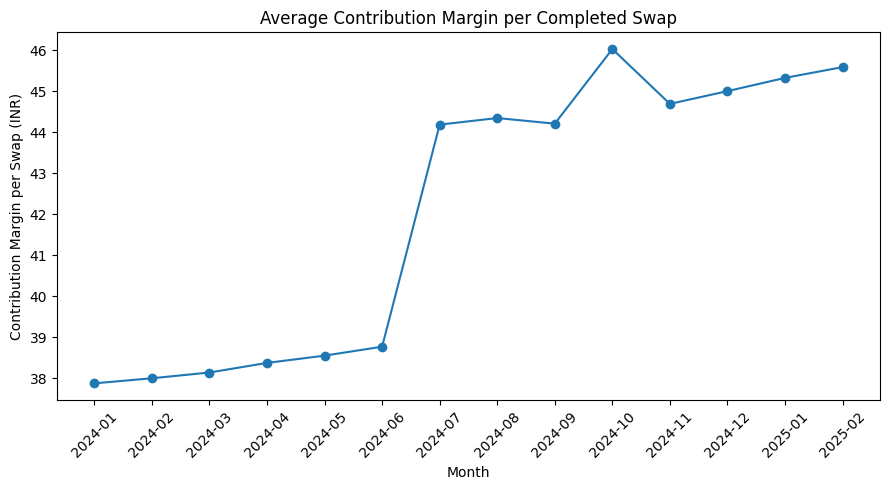

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    monthly_margin['month'],
    monthly_margin['avg_margin_per_swap'],
    marker='o'
)

plt.title('Average Contribution Margin per Completed Swap')
plt.xlabel('Month')
plt.ylabel('Contribution Margin per Swap (INR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
rider_swaps = final_data[
    final_data['event_type'] == 'swap_completed'
].copy()

rider_activity = (
    rider_swaps
    .groupby('rider_id')
    .agg(
        first_swap=('event_ts', 'min'),
        last_swap=('event_ts', 'max'),
        total_swaps=('event_id', 'count')
    )
    .reset_index()
)

rider_activity['returned'] = np.where(
    rider_activity['total_swaps'] > 1,
    'Returned',
    'Did not return'
)

retention_summary = (
    rider_activity['returned']
    .value_counts()
    .reset_index()
)

retention_summary.columns = [
    'Return Status',
    'Rider Count'
]

retention_summary['Percentage'] = (
    retention_summary['Rider Count']
    / retention_summary['Rider Count'].sum()
    * 100
)

display(retention_summary.round(2))

,Return Status,Rider Count,Percentage
0,Returned,14377,99.35
1,Did not return,94,0.65


In [ ]:
first_swaps = (
    rider_swaps
    .sort_values('event_ts')
    .groupby('rider_id')
    .first()
    .reset_index()
)

first_swaps = first_swaps.merge(
    rider_activity[['rider_id', 'returned']],
    on='rider_id',
    how='left'
)

retention_experience = (
    first_swaps
    .groupby('returned')
    .agg(
        riders=('rider_id', 'count'),
        avg_queue_wait_sec=('queue_wait_sec', 'mean'),
        avg_amount_charged_inr=('amount_charged_inr', 'mean'),
        avg_energy_kwh=('energy_to_recharge_kwh', 'mean')
    )
    .reset_index()
)

display(retention_experience.round(2))

,returned,riders,avg_queue_wait_sec,avg_amount_charged_inr,avg_energy_kwh
0,Did not return,94,245.73,71.22,2.45
1,Returned,14377,242.22,64.18,2.34


In [ ]:
first_swaps_city = first_swaps.merge(
    stations[['station_id', 'city']],
    on='station_id',
    how='left'
)

retention_by_city = (
    first_swaps_city
    .groupby('city')
    .agg(
        riders=('rider_id', 'count'),
        returned_riders=('returned', lambda x: (x == 'Returned').sum())
    )
    .reset_index()
)

retention_by_city['return_rate_pct'] = (
    retention_by_city['returned_riders']
    / retention_by_city['riders']
    * 100
)

display(
    retention_by_city
    .sort_values('return_rate_pct', ascending=False)
    .round(2)
)

,city,riders,returned_riders,return_rate_pct
4,Mumbai,2081,2073,99.62
1,Delhi NCR,2794,2779,99.46
2,Hyderabad,2522,2507,99.41
5,Pune,2122,2108,99.34
3,Jaipur,1791,1777,99.22
0,Bengaluru,3161,3133,99.11


In [ ]:
first_swaps = (
    rider_swaps
    .sort_values('event_ts')
    .groupby('rider_id')
    .first()
    .reset_index()
)

first_swaps = first_swaps.merge(
    rider_activity[['rider_id', 'returned']],
    on='rider_id',
    how='left'
)

retention_experience = (
    first_swaps
    .groupby('returned')
    .agg(
        riders=('rider_id', 'count'),
        avg_queue_wait_sec=('queue_wait_sec', 'mean'),
        avg_amount_charged_inr=('amount_charged_inr', 'mean'),
        avg_energy_kwh=('energy_to_recharge_kwh', 'mean')
    )
    .reset_index()
)

display(retention_experience.round(2))

,returned,riders,avg_queue_wait_sec,avg_amount_charged_inr,avg_energy_kwh
0,Did not return,94,245.73,71.22,2.45
1,Returned,14377,242.22,64.18,2.34


In [ ]:
first_swaps_city = first_swaps.merge(
    stations[['station_id', 'city']],
    on='station_id',
    how='left'
)

retention_by_city = (
    first_swaps_city
    .groupby('city')
    .agg(
        riders=('rider_id', 'count'),
        returned_riders=(
            'returned',
            lambda x: (x == 'Returned').sum()
        )
    )
    .reset_index()
)

retention_by_city['return_rate_pct'] = (
    retention_by_city['returned_riders']
    / retention_by_city['riders']
    * 100
)

display(
    retention_by_city
    .sort_values('return_rate_pct', ascending=False)
    .round(2)
)

,city,riders,returned_riders,return_rate_pct
4,Mumbai,2081,2073,99.62
1,Delhi NCR,2794,2779,99.46
2,Hyderabad,2522,2507,99.41
5,Pune,2122,2108,99.34
3,Jaipur,1791,1777,99.22
0,Bengaluru,3161,3133,99.11


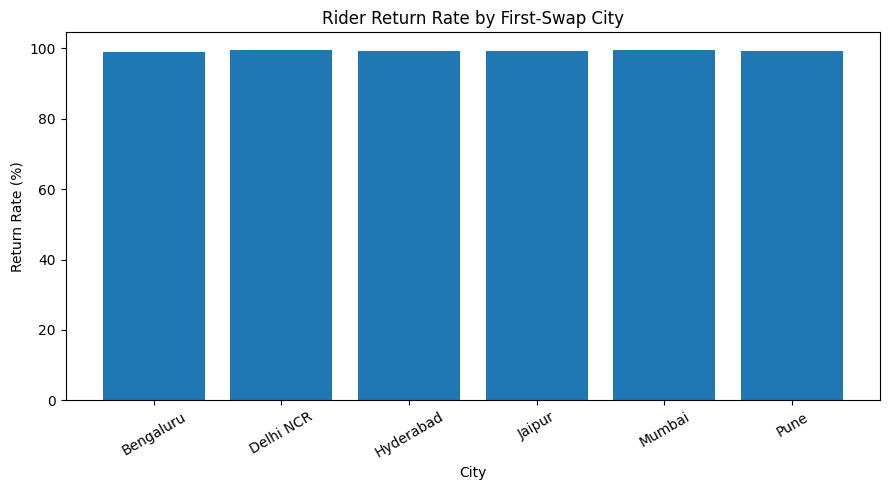

In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(
    retention_by_city['city'],
    retention_by_city['return_rate_pct']
)

plt.title('Rider Return Rate by First-Swap City')
plt.xlabel('City')
plt.ylabel('Return Rate (%)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
ticket_summary = pd.DataFrame({
    'Metric': [
        'Total Support Tickets',
        'Tickets with CSAT',
        'Tickets without CSAT',
        'CSAT Response Rate (%)',
        'Average Resolution Time (hours)',
        'Average CSAT'
    ],
    'Value': [
        len(support_tickets),
        support_tickets['csat_score'].notna().sum(),
        support_tickets['csat_score'].isna().sum(),
        support_tickets['csat_score'].notna().mean() * 100,
        support_tickets['resolution_hours'].mean(),
        support_tickets['csat_score'].mean()
    ]
})

display(ticket_summary.round(2))

,Metric,Value
0,Total Support Tickets,44000.00
1,Tickets with CSAT,15129.00
2,Tickets without CSAT,28871.00
3,CSAT Response Rate (%),34.38
4,Average Resolution Time (hours),15.95
5,Average CSAT,3.56


In [ ]:
ticket_category = (
    support_tickets
    .groupby('category')
    .agg(
        ticket_count=('ticket_id', 'count'),
        avg_resolution_hours=('resolution_hours', 'mean'),
        avg_csat=('csat_score', 'mean')
    )
    .reset_index()
)

ticket_category['ticket_share_pct'] = (
    ticket_category['ticket_count']
    / ticket_category['ticket_count'].sum()
    * 100
)

display(
    ticket_category
    .sort_values('ticket_count', ascending=False)
    .round(2)
)

,category,ticket_count,avg_resolution_hours,avg_csat,ticket_share_pct
4,no_battery_available,11647,15.96,3.60,26.47
5,other,9484,16.04,3.57,21.55
3,low_range,6636,15.99,3.53,15.08
0,app_issue,5787,15.89,3.54,13.15
2,long_queue,5731,15.84,3.51,13.02
1,billing_dispute,4715,15.91,3.57,10.72


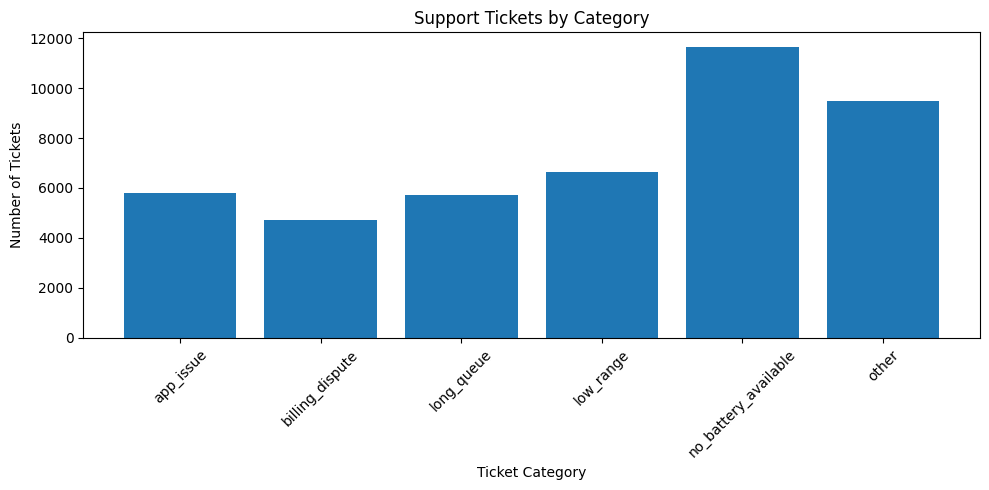

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    ticket_category['category'],
    ticket_category['ticket_count']
)

plt.title('Support Tickets by Category')
plt.xlabel('Ticket Category')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
ticket_station = support_tickets.merge(
    stations[
        ['station_id', 'city', 'zone', 'location_type']
    ],
    on='station_id',
    how='left'
)

ticket_city = (
    ticket_station
    .groupby('city')
    .agg(
        ticket_count=('ticket_id', 'count'),
        avg_resolution_hours=('resolution_hours', 'mean'),
        avg_csat=('csat_score', 'mean')
    )
    .reset_index()
)

ticket_city['ticket_share_pct'] = (
    ticket_city['ticket_count']
    / ticket_city['ticket_count'].sum()
    * 100
)

display(
    ticket_city
    .sort_values('ticket_count', ascending=False)
    .round(2)
)

,city,ticket_count,avg_resolution_hours,avg_csat,ticket_share_pct
1,Delhi NCR,9907,16.06,3.56,23.72
2,Hyderabad,8594,15.84,3.55,20.57
0,Bengaluru,7187,15.81,3.57,17.20
3,Jaipur,6536,16.09,3.56,15.65
5,Pune,5032,16.07,3.57,12.05
4,Mumbai,4517,15.91,3.53,10.81


In [ ]:
top_complaint_stations = (
    ticket_station
    .groupby('station_id')
    .agg(
        ticket_count=('ticket_id', 'count'),
        avg_resolution_hours=('resolution_hours', 'mean'),
        avg_csat=('csat_score', 'mean')
    )
    .reset_index()
    .merge(
        stations[
            ['station_id', 'city', 'location_type']
        ],
        on='station_id',
        how='left'
    )
)

display(
    top_complaint_stations
    .sort_values('ticket_count', ascending=False)
    .head(15)
    .round(2)
)

,station_id,ticket_count,avg_resolution_hours,avg_csat,city,location_type
71,STN-HYD-072,689,15.52,3.66,Hyderabad,commercial_hub
42,STN-DEL-043,681,16.46,3.50,Delhi NCR,commercial_hub
93,STN-JAI-138,674,15.91,3.52,Jaipur,market
96,STN-JAI-141,645,16.95,3.49,Jaipur,commercial_hub
49,STN-DEL-050,639,16.42,3.62,Delhi NCR,commercial_hub
95,STN-JAI-140,626,16.23,3.53,Jaipur,commercial_hub
69,STN-HYD-070,618,15.65,3.41,Hyderabad,market
92,STN-JAI-137,586,16.07,3.63,Jaipur,commercial_hub
89,STN-JAI-134,584,15.99,3.47,Jaipur,commercial_hub
64,STN-HYD-065,551,15.68,3.62,Hyderabad,commercial_hub


In [ ]:
complaint_failure = station_health[
    [
        'station_id',
        'city',
        'total_attempts',
        'failure_rate_pct',
        'abandonment_rate_pct',
        'ticket_count',
        'avg_resolution_hours',
        'avg_csat'
    ]
].copy()

display(
    complaint_failure
    .sort_values(
        ['failure_rate_pct', 'ticket_count'],
        ascending=False
    )
    .head(15)
    .round(2)
)

,station_id,city,total_attempts,failure_rate_pct,abandonment_rate_pct,ticket_count,avg_resolution_hours,avg_csat
30,STN-DEL-037,Delhi NCR,19641,4.77,2.11,440,16.07,3.50
72,STN-JAI-133,Jaipur,19586,4.75,2.25,339,15.70,3.71
81,STN-JAI-142,Jaipur,23676,4.56,2.29,436,15.61,3.67
77,STN-JAI-138,Jaipur,33865,4.55,2.12,674,15.91,3.52
78,STN-JAI-139,Jaipur,23110,4.53,2.19,400,16.57,3.72
75,STN-JAI-136,Jaipur,21132,4.51,2.08,368,15.60,3.53
32,STN-DEL-039,Delhi NCR,21798,4.45,2.06,433,16.21,3.64
76,STN-JAI-137,Jaipur,29569,4.41,2.12,586,16.07,3.63
79,STN-JAI-140,Jaipur,30495,4.39,1.97,626,16.23,3.53
42,STN-DEL-049,Delhi NCR,15838,4.37,1.98,286,15.47,3.47


In [ ]:
battery_soh_summary = batteries['current_soh_pct'].describe()

display(
    battery_soh_summary.to_frame(name='Current SOH (%)').round(2)
)

,Current SOH (%)
count,6500.00
mean,76.61
std,8.82
min,55.40
25%,78.40
50%,79.80
75%,80.80
max,88.60


In [ ]:
supplier_soh = (
    batteries
    .groupby('supplier')
    .agg(
        battery_count=('battery_id', 'count'),
        avg_current_soh=('current_soh_pct', 'mean'),
        avg_initial_soh=('initial_soh_pct', 'mean'),
        avg_capacity_kwh=('rated_capacity_kwh', 'mean')
    )
    .reset_index()
)

display(
    supplier_soh
    .sort_values('avg_current_soh')
    .round(2)
)

,supplier,battery_count,avg_current_soh,avg_initial_soh,avg_capacity_kwh
2,Kyron,1638,63.75,99.21,2.52
1,Cellora,3555,80.93,99.18,2.49
0,Amptek,1307,81.01,99.19,2.53


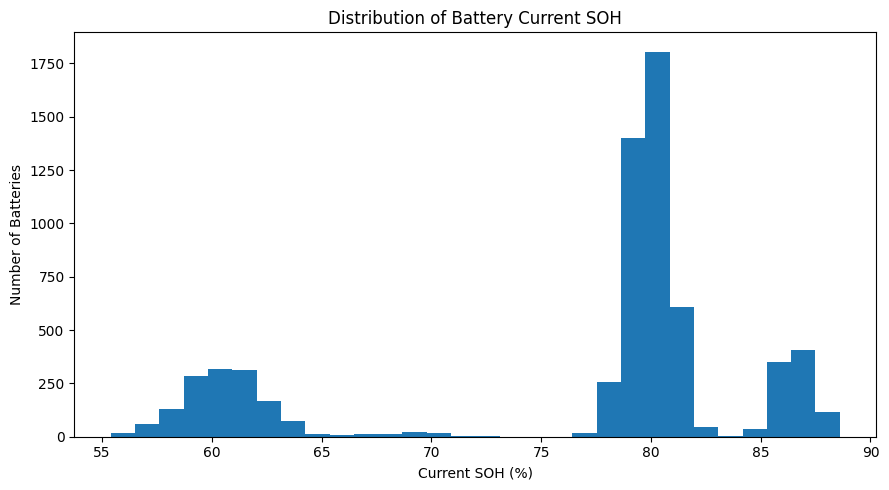

In [ ]:
plt.figure(figsize=(9, 5))

plt.hist(
    batteries['current_soh_pct'].dropna(),
    bins=30
)

plt.title('Distribution of Battery Current SOH')
plt.xlabel('Current SOH (%)')
plt.ylabel('Number of Batteries')
plt.tight_layout()
plt.show()

In [ ]:
lot_soh = (
    batteries
    .groupby('manufacturing_lot')
    .agg(
        battery_count=('battery_id', 'count'),
        avg_current_soh=('current_soh_pct', 'mean'),
        avg_initial_soh=('initial_soh_pct', 'mean'),
        avg_capacity_kwh=('rated_capacity_kwh', 'mean')
    )
    .reset_index()
)

display(
    lot_soh
    .sort_values('avg_current_soh')
    .head(15)
    .round(2)
)

,manufacturing_lot,battery_count,avg_current_soh,avg_initial_soh,avg_capacity_kwh
45,KY-2409,481,60.92,99.21,2.21
43,KY-2407,480,60.99,99.17,2.26
44,KY-2408,500,61.05,99.22,2.26
20,CE-2307,143,80.60,99.19,2.36
7,AM-2410,81,80.60,99.16,2.40
29,CE-2404,158,80.61,99.14,2.39
23,CE-2310,117,80.62,99.17,2.38
30,CE-2405,127,80.64,99.17,2.36
2,AM-2405,88,80.64,99.19,2.47
19,CE-2306,122,80.65,99.21,2.39


In [ ]:
battery_swap_analysis = swap_events_clean[
    swap_events_clean['event_type'] == 'swap_completed'
].merge(
    batteries[
        [
            'battery_id',
            'pack_type',
            'supplier',
            'manufacturing_lot',
            'current_soh_pct',
            'rated_capacity_kwh'
        ]
    ],
    left_on='battery_out_id',
    right_on='battery_id',
    how='left'
)

soh_performance = (
    battery_swap_analysis
    .groupby('pack_type')
    .agg(
        completed_swaps=('event_id', 'count'),
        avg_soh=('current_soh_pct', 'mean'),
        avg_delivered_energy_kwh=('energy_to_recharge_kwh', 'mean'),
        avg_soc_out_pct=('soc_out_pct', 'mean'),
        avg_km_since_last_swap=('km_since_last_swap', 'mean')
    )
    .reset_index()
)

display(soh_performance.round(2))

,pack_type,completed_swaps,avg_soh,avg_delivered_energy_kwh,avg_soc_out_pct,avg_km_since_last_swap
0,2W_2.1kWh,1998171,77.51,1.93,96.66,63.34
1,3W_4.8kWh,235037,85.17,4.52,96.66,93.65


In [ ]:
battery_swap_analysis['soh_band'] = pd.cut(
    battery_swap_analysis['current_soh_pct'],
    bins=[0, 95, 98, 100, 105],
    labels=[
        'Below 95%',
        '95–98%',
        '98–100%',
        'Above 100%'
    ]
)

soh_band_analysis = (
    battery_swap_analysis
    .groupby('soh_band', observed=False)
    .agg(
        completed_swaps=('event_id', 'count'),
        avg_delivered_energy_kwh=('energy_to_recharge_kwh', 'mean'),
        avg_soc_out_pct=('soc_out_pct', 'mean'),
        avg_km_since_last_swap=('km_since_last_swap', 'mean')
    )
    .reset_index()
)

display(soh_band_analysis.round(2))

,soh_band,completed_swaps,avg_delivered_energy_kwh,avg_soc_out_pct,avg_km_since_last_swap
0,Below 95%,2233208,2.2,96.66,66.53
1,95–98%,0,NaN,NaN,NaN
2,98–100%,0,NaN,NaN,NaN
3,Above 100%,0,NaN,NaN,NaN


In [ ]:
station_generation = station_health.groupby(
    'charger_generation'
).agg(
    stations=('station_id', 'nunique'),
    total_attempts=('total_attempts', 'sum'),
    failed_attempts=('failed_attempts', 'sum'),
    abandoned_attempts=('abandoned_attempts', 'sum'),
    avg_failure_rate=('failure_rate_pct', 'mean')
).reset_index()

station_generation['weighted_failure_rate_pct'] = (
    station_generation['failed_attempts']
    / station_generation['total_attempts']
    * 100
)

station_generation['weighted_abandonment_rate_pct'] = (
    station_generation['abandoned_attempts']
    / station_generation['total_attempts']
    * 100
)

display(station_generation.round(2))

,charger_generation,stations,total_attempts,failed_attempts,abandoned_attempts,avg_failure_rate,weighted_failure_rate_pct,weighted_abandonment_rate_pct
0,Gen1,51,1224390,46729,22159,3.80,3.82,1.81
1,Gen2,64,1072344,30314,14380,2.79,2.83,1.34
2,Gen3,9,62508,1614,759,2.41,2.58,1.21


In [ ]:
station_location = station_health.groupby(
    'location_type'
).agg(
    stations=('station_id', 'nunique'),
    total_attempts=('total_attempts', 'sum'),
    failed_attempts=('failed_attempts', 'sum'),
    abandoned_attempts=('abandoned_attempts', 'sum')
).reset_index()

station_location['failure_rate_pct'] = (
    station_location['failed_attempts']
    / station_location['total_attempts']
    * 100
)

station_location['abandonment_rate_pct'] = (
    station_location['abandoned_attempts']
    / station_location['total_attempts']
    * 100
)

display(
    station_location
    .sort_values('failure_rate_pct', ascending=False)
    .round(2)
)

,location_type,stations,total_attempts,failed_attempts,abandoned_attempts,failure_rate_pct,abandonment_rate_pct
2,market,33,770616,26767,12683,3.47,1.65
5,transit_hub,6,105534,3586,1690,3.40,1.60
0,commercial_hub,43,1032863,34849,16635,3.37,1.61
4,tech_park,6,90460,2820,1307,3.12,1.44
3,residential,19,216081,6663,3099,3.08,1.43
1,highway_fuel_pump,17,143688,3972,1884,2.76,1.31


In [ ]:
station_connectivity = station_health.groupby(
    'connectivity_tier'
).agg(
    stations=('station_id', 'nunique'),
    total_attempts=('total_attempts', 'sum'),
    failed_attempts=('failed_attempts', 'sum'),
    abandoned_attempts=('abandoned_attempts', 'sum')
).reset_index()

station_connectivity['failure_rate_pct'] = (
    station_connectivity['failed_attempts']
    / station_connectivity['total_attempts']
    * 100
)

station_connectivity['abandonment_rate_pct'] = (
    station_connectivity['abandoned_attempts']
    / station_connectivity['total_attempts']
    * 100
)

display(station_connectivity.round(2))

,connectivity_tier,stations,total_attempts,failed_attempts,abandoned_attempts,failure_rate_pct,abandonment_rate_pct
0,fair,24,412724,14382,6792,3.48,1.65
1,good,82,1548790,50531,23902,3.26,1.54
2,poor,18,397728,13744,6604,3.46,1.66


In [ ]:
analysis_end_date = final_data['event_ts'].max()

stations_age = stations.copy()

stations_age['station_age_days'] = (
    analysis_end_date - stations_age['commissioned_date']
).dt.days

stations_age['age_group'] = pd.cut(
    stations_age['station_age_days'],
    bins=[-1, 180, 365, 730, float('inf')],
    labels=[
        '<6 months',
        '6–12 months',
        '1–2 years',
        '>2 years'
    ]
)

station_age_analysis = station_health.merge(
    stations_age[['station_id', 'age_group']],
    on='station_id',
    how='left'
)

age_performance = station_age_analysis.groupby(
    'age_group',
    observed=False
).agg(
    stations=('station_id', 'nunique'),
    total_attempts=('total_attempts', 'sum'),
    failed_attempts=('failed_attempts', 'sum'),
    abandoned_attempts=('abandoned_attempts', 'sum')
).reset_index()

age_performance['failure_rate_pct'] = (
    age_performance['failed_attempts']
    / age_performance['total_attempts']
    * 100
)

age_performance['abandonment_rate_pct'] = (
    age_performance['abandoned_attempts']
    / age_performance['total_attempts']
    * 100
)

display(age_performance.round(2))

,age_group,stations,total_attempts,failed_attempts,abandoned_attempts,failure_rate_pct,abandonment_rate_pct
0,<6 months,30,225833,6023,2812,2.67,1.25
1,6–12 months,2,17562,469,216,2.67,1.23
2,1–2 years,92,2115847,72165,34270,3.41,1.62
3,>2 years,0,0,0,0,NaN,NaN


In [ ]:
pricing_analysis = final_data[
    final_data['event_type'] == 'swap_completed'
].copy()

tariff_performance = (
    pricing_analysis
    .groupby('tariff_code')
    .agg(
        completed_swaps=('event_id', 'count'),
        avg_list_price_inr=('list_price_inr', 'mean'),
        avg_discount_inr=('discount_inr', 'mean'),
        avg_amount_charged_inr=('amount_charged_inr', 'mean'),
        total_revenue_inr=('amount_charged_inr', 'sum')
    )
    .reset_index()
)

display(tariff_performance.round(2))

,tariff_code,completed_swaps,avg_list_price_inr,avg_discount_inr,avg_amount_charged_inr,total_revenue_inr
0,OFFPEAK,14356,67.34,0.00,59.35,851962.0
1,PARTNER,1451821,69.04,8.13,61.46,89227606.7
2,PEAK,67386,67.42,0.00,82.42,5553865.0
3,STD,660030,65.58,0.00,65.58,43285725.0


In [ ]:
discount_analysis = pd.DataFrame({
    'Metric': [
        'Average List Price',
        'Average Discount',
        'Average Amount Charged',
        'Average Discount Percentage'
    ],
    'Value': [
        pricing_analysis['list_price_inr'].mean(),
        pricing_analysis['discount_inr'].mean(),
        pricing_analysis['amount_charged_inr'].mean(),
        (
            pricing_analysis['discount_inr']
            / pricing_analysis['list_price_inr']
            * 100
        ).mean()
    ]
})

display(discount_analysis.round(2))

,Metric,Value
0,Average List Price,67.94
1,Average Discount,5.38
2,Average Amount Charged,63.33
3,Average Discount Percentage,7.89


In [ ]:
pricing_analysis['month'] = (
    pricing_analysis['event_ts']
    .dt.to_period('M')
    .astype(str)
)

monthly_pricing = (
    pricing_analysis
    .groupby('month')
    .agg(
        completed_swaps=('event_id', 'count'),
        avg_list_price_inr=('list_price_inr', 'mean'),
        avg_discount_inr=('discount_inr', 'mean'),
        avg_amount_charged_inr=('amount_charged_inr', 'mean'),
        total_revenue_inr=('amount_charged_inr', 'sum')
    )
    .reset_index()
)

display(monthly_pricing.round(2))

,month,completed_swaps,avg_list_price_inr,avg_discount_inr,avg_amount_charged_inr,total_revenue_inr
0,2024-01,103508,64.45,4.57,59.89,6198803.40
1,2024-02,104437,64.48,4.58,59.90,6256296.00
2,2024-03,116148,64.41,4.55,59.86,6952642.00
3,2024-04,120117,64.50,4.52,59.98,7204036.20
4,2024-05,125454,64.39,4.51,59.89,7513212.80
5,2024-06,130880,64.29,4.48,59.81,7827373.00
6,2024-07,148611,69.90,4.86,65.05,9666799.25
7,2024-08,161688,69.87,4.88,65.00,10509533.60
8,2024-09,184051,69.55,4.87,64.67,11903273.70
9,2024-10,216551,69.47,4.90,66.26,14348597.95


In [ ]:
pricing_analysis['hour'] = pricing_analysis['event_ts'].dt.hour

pricing_analysis['period'] = np.where(
    pricing_analysis['hour'].between(18, 21),
    'Peak',
    'Off-Peak'
)

peak_analysis = (
    pricing_analysis
    .groupby('period')
    .agg(
        completed_swaps=('event_id', 'count'),
        avg_amount_charged_inr=('amount_charged_inr', 'mean'),
        avg_discount_inr=('discount_inr', 'mean'),
        total_revenue_inr=('amount_charged_inr', 'sum')
    )
    .reset_index()
)

display(peak_analysis.round(2))

,period,completed_swaps,avg_amount_charged_inr,avg_discount_inr,total_revenue_inr
0,Off-Peak,1333936,63.44,5.86,84626573.75
1,Peak,859657,63.16,4.63,54292584.95


In [ ]:
partner_analysis = fleet_partners.copy()

partner_analysis['effective_discount_pct'] = np.where(
    partner_analysis['discount_pct_after_amendment'].notna(),
    partner_analysis['discount_pct_after_amendment'],
    partner_analysis['discount_pct']
)

partner_summary = (
    partner_analysis
    .groupby('partner_segment')
    .agg(
        partners=('partner_id', 'count'),
        avg_discount_pct=('effective_discount_pct', 'mean'),
        avg_payment_terms_days=('payment_terms_days', 'mean'),
        peak_surcharge_partners=('peak_surcharge_billable', lambda x: (x == 'Y').sum())
    )
    .reset_index()
)

display(partner_summary.round(2))

,partner_segment,partners,avg_discount_pct,avg_payment_terms_days,peak_surcharge_partners
0,bike_taxi,2,5.50,15.0,2
1,cargo_3w,2,7.50,37.5,2
2,ecom_logistics,3,12.33,30.0,3
3,food_delivery,3,9.67,30.0,2
4,quick_commerce,2,18.50,37.5,1


In [ ]:
partner_details = partner_analysis[
    [
        'partner_id',
        'partner_name',
        'partner_segment',
        'vehicle_class',
        'contract_type',
        'discount_pct',
        'discount_pct_after_amendment',
        'effective_discount_pct',
        'peak_surcharge_billable',
        'payment_terms_days',
        'cities_active'
    ]
].copy()

display(partner_details.sort_values('effective_discount_pct', ascending=False))

,partner_id,partner_name,partner_segment,vehicle_class,contract_type,discount_pct,discount_pct_after_amendment,effective_discount_pct,peak_surcharge_billable,payment_terms_days,cities_active
2,FP-03,ZipDrop,quick_commerce,2W,volume_tiered,12.0,28.0,28.0,N,45,BLR|DEL|HYD|PUN|MUM|JAI
1,FP-02,ParcelNest,ecom_logistics,2W,pay_per_swap,15.0,NaN,15.0,Y,30,BLR|DEL|HYD|MUM
9,FP-10,MetroMove,ecom_logistics,mixed,volume_tiered,12.0,NaN,12.0,Y,30,BLR|MUM
4,FP-05,Swiggle Go,food_delivery,2W,volume_tiered,11.0,NaN,11.0,N,30,BLR|PUN|MUM
10,FP-11,LastMileHub,ecom_logistics,2W,pay_per_swap,10.0,NaN,10.0,Y,30,HYD|PUN
0,FP-01,FeastFly,food_delivery,2W,volume_tiered,10.0,NaN,10.0,Y,30,BLR|DEL|HYD|PUN|MUM|JAI
6,FP-07,QuickCart,quick_commerce,2W,pay_per_swap,9.0,NaN,9.0,Y,30,DEL|HYD
3,FP-04,CargoTuk,cargo_3w,3W,pay_per_swap,8.0,NaN,8.0,Y,30,DEL|HYD|JAI
7,FP-08,DabbaXpress,food_delivery,2W,pay_per_swap,8.0,NaN,8.0,Y,30,PUN|MUM
8,FP-09,HaulKing,cargo_3w,3W,pay_per_swap,7.0,NaN,7.0,Y,45,JAI|DEL


In [ ]:
contract_analysis = (
    partner_analysis
    .groupby('contract_type')
    .agg(
        partners=('partner_id', 'count'),
        avg_discount_pct=('effective_discount_pct', 'mean'),
        avg_payment_terms_days=('payment_terms_days', 'mean'),
        peak_surcharge_partners=(
            'peak_surcharge_billable',
            lambda x: (x == 'Y').sum()
        )
    )
    .reset_index()
)

display(contract_analysis.round(2))

,contract_type,partners,avg_discount_pct,avg_payment_terms_days,peak_surcharge_partners
0,pay_per_swap,8,8.50,28.12,8
1,volume_tiered,4,15.25,33.75,2


In [ ]:
findings_summary = pd.DataFrame({
    'Analysis Area': [
        'Network Performance',
        'Failure Analysis',
        'Station Performance',
        'Customer Experience',
        'Battery Health',
        'Pricing',
        'Fleet Partners',
        'Rider Retention'
    ],
    'What We Analyzed': [
        'Completed swaps, revenue, failure and abandonment rates',
        'Failure reasons and failure patterns by time and city',
        'Charger generation, location, connectivity and station age',
        'Support tickets, resolution time and CSAT',
        'SOH, suppliers, manufacturing lots and delivered performance',
        'Tariffs, discounts, revenue and peak/off-peak behavior',
        'Discounts, contract types, payment terms and surcharges',
        'Return behavior and first-swap experience'
    ],
    'Business Question': [
        'How is the network performing over time?',
        'Why are swaps failing?',
        'Which station characteristics are associated with operational issues?',
        'What customer-experience issues are visible?',
        'Are battery characteristics associated with swap performance?',
        'How do pricing patterns relate to revenue?',
        'What are the partner contract economics?',
        'What factors are associated with riders returning?'
    ]
})

display(findings_summary)

,Analysis Area,What We Analyzed,Business Question
0,Network Performance,"Completed swaps, revenue, failure and abandonm...",How is the network performing over time?
1,Failure Analysis,Failure reasons and failure patterns by time a...,Why are swaps failing?
2,Station Performance,"Charger generation, location, connectivity and...",Which station characteristics are associated w...
3,Customer Experience,"Support tickets, resolution time and CSAT",What customer-experience issues are visible?
4,Battery Health,"SOH, suppliers, manufacturing lots and deliver...",Are battery characteristics associated with sw...
5,Pricing,"Tariffs, discounts, revenue and peak/off-peak ...",How do pricing patterns relate to revenue?
6,Fleet Partners,"Discounts, contract types, payment terms and s...",What are the partner contract economics?
7,Rider Retention,Return behavior and first-swap experience,What factors are associated with riders return...


In [ ]:
final_kpis = pd.DataFrame({
    'KPI': [
        'Total Attempts',
        'Completed Swaps',
        'Failure Rate (%)',
        'Abandonment Rate (%)',
        'Total Revenue (INR)',
        'Avg Contribution Margin / Swap (INR)',
        'Support Tickets',
        'Average CSAT'
    ],
    'Value': [
        total_attempts,
        completed_swaps,
        failure_rate,
        abandonment_rate,
        revenue,
        margin_data['contribution_margin_inr'].mean(),
        len(support_tickets),
        support_tickets['csat_score'].mean()
    ]
})

display(final_kpis.round(2))

,KPI,Value
0,Total Attempts,2.317697e+06
1,Completed Swaps,2.193593e+06
2,Failure Rate (%),3.340000e+00
3,Abandonment Rate (%),1.580000e+00
4,Total Revenue (INR),1.389192e+08
5,Avg Contribution Margin / Swap (INR),4.282000e+01
6,Support Tickets,4.400000e+04
7,Average CSAT,3.560000e+00


In [ ]:
final_findings = pd.DataFrame({

    'Finding Area': [
        'Monthly Performance',
        'Failure Reasons',
        'City Performance',
        'Hourly Performance',
        'Battery Availability',
        'Station Analysis'
    ],

    'Key Finding': [
        'Failure rate increased from 2.73% in January 2024 to a peak of 8.04% in May 2024, then returned to around 2.6–2.7% from July 2024 onward.',
        'Failed swaps were mainly caused by no charged battery rather than system errors.',
        'Failure rates differed considerably across cities, with Jaipur showing the highest observed rate.',
        'Battery-related failure rates were highest during the evening period, especially around 19:00–22:00.',
        'Average battery availability was lowest around 15:00–16:00, while the highest failure period occurred later in the evening.',
        'Station-level analysis combines operational failure rates with customer support activity to identify locations requiring further investigation.'
    ],

    'Evidence': [
        'Monthly performance analysis',
        'Failure reason breakdown',
        'City performance analysis',
        'Hourly battery-failure analysis',
        'Hourly battery-status analysis',
        'Station health and complaint analysis'
    ]
})

display(final_findings)

,Finding Area,Key Finding,Evidence
0,Monthly Performance,Failure rate increased from 2.73% in January 2...,Monthly performance analysis
1,Failure Reasons,Failed swaps were mainly caused by no charged ...,Failure reason breakdown
2,City Performance,Failure rates differed considerably across cit...,City performance analysis
3,Hourly Performance,Battery-related failure rates were highest dur...,Hourly battery-failure analysis
4,Battery Availability,Average battery availability was lowest around...,Hourly battery-status analysis
5,Station Analysis,Station-level analysis combines operational fa...,Station health and complaint analysis


In [ ]:
recommendations = pd.DataFrame({

    'Recommendation Area': [
        'Battery Availability',
        'Peak-Hour Operations',
        'Station Performance',
        'Customer Experience',
        'Battery Health',
        'Data Quality'
    ],

    'Recommendation': [
        'Improve monitoring and redistribution of charged batteries during high-demand periods.',
        'Investigate evening demand patterns and operational bottlenecks to reduce battery-related failures.',
        'Prioritize detailed investigation of stations with elevated failure rates and customer complaint volume.',
        'Track queue-related complaints, resolution time, and CSAT together with station-level performance.',
        'Monitor battery SOH by supplier, manufacturing lot, and pack type to identify potential quality differences.',
        'Continue systematic data-quality validation for telemetry, timestamps, duplicate events, and inconsistent location data.'
    ],

    'Expected Impact': [
        'Reduce failed and abandoned swap attempts.',
        'Improve service reliability during peak periods.',
        'Identify and address station-specific operational issues.',
        'Improve rider satisfaction and retention.',
        'Support proactive battery maintenance and replacement decisions.',
        'Improve reliability of future operational analysis and reporting.'
    ]
})

display(recommendations)

,Recommendation Area,Recommendation,Expected Impact
0,Battery Availability,Improve monitoring and redistribution of charg...,Reduce failed and abandoned swap attempts.
1,Peak-Hour Operations,Investigate evening demand patterns and operat...,Improve service reliability during peak periods.
2,Station Performance,Prioritize detailed investigation of stations ...,Identify and address station-specific operatio...
3,Customer Experience,"Track queue-related complaints, resolution tim...",Improve rider satisfaction and retention.
4,Battery Health,"Monitor battery SOH by supplier, manufacturing...",Support proactive battery maintenance and repl...
5,Data Quality,Continue systematic data-quality validation fo...,Improve reliability of future operational anal...


In [ ]:
final_conclusion = """
CONCLUSION

The analysis of VoltRelay's EV battery-swapping network shows that overall
network performance was generally stable, but specific periods and operating
conditions created higher service failures.

The main operational concern was battery availability, with failure rates
showing a clear spike during April–June 2024 before returning to lower levels
from July 2024 onward. Peak-hour and station-level analysis also highlighted
areas requiring further operational investigation.

Battery health, station performance, customer support activity, and data
quality should be monitored together rather than independently.

Overall, the analysis provides an evidence-based view of network reliability,
customer experience, battery performance, and operational improvement
opportunities.
"""

print(final_conclusion)


CONCLUSION

The analysis of VoltRelay's EV battery-swapping network shows that overall
network performance was generally stable, but specific periods and operating
conditions created higher service failures.

The main operational concern was battery availability, with failure rates
showing a clear spike during April–June 2024 before returning to lower levels
from July 2024 onward. Peak-hour and station-level analysis also highlighted
areas requiring further operational investigation.

Battery health, station performance, customer support activity, and data
quality should be monitored together rather than independently.

Overall, the analysis provides an evidence-based view of network reliability,
customer experience, battery performance, and operational improvement
opportunities.

